# Choose priors for models

models are 

**Simple model**
$$
\ln{F_{i,k}} = \alpha_k + \beta_k \frac{T_{i,j} - 10^{\circ} \text{C}}{10^{\circ} \text{C}} + \zeta\theta\\
i = 1 \ldots \text{\# observations} \\
k \in \left[  \mathrm{N_2O} ; \mathrm{CH_4} \right] \\
T_i = \text{ Observed air temperature (K)} \\
\theta = \text{ Mean of measured Tomst soil water content}
$$

**Full model**
$$
\ln{F_{i,k}} = \alpha_k + \beta_k f(T_{i}) + \zeta\theta + \sum_{j=1}^{N} \gamma_{j,k}x_{i,j} + \delta_{j,k} x_{i,j} f(T_{i}) \\

f(T_{i}) = \frac{T_{i,j} - 10^{\circ} \text{C}}{10^{\circ} \text{C}}
$$

Full model is run with 9, 5, 6, 4 and 3 surface types and with and without $\theta$ and $\delta$ terms.

The goal is to define free parameters of the priors (mainly rate parameter for temperature sensitivity, and standard deviation for $\gamma$) such that the prior predictive distribution covers at least twice the width of the distribution in poisitve and negative direction. The goal is to have the same free parameter values for all the models

In [ ]:
import pandas as pd
from dotenv import load_dotenv; load_dotenv()

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neighbors import KernelDensity

import pymc as pm
import arviz as az

%matplotlib widget
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def simple_model_theta(T, theta, y, alpha_mean, alpha_std, lambda_beta, lambda_epsilon, zeta_std):
    with pm.Model() as model:
        alpha = pm.Normal('alpha', mu=alpha_mean, sigma=alpha_std)
        beta = pm.Exponential('beta', lambda_beta)
        epsilon = pm.Exponential("sigma", lambda_epsilon)
        zeta = pm.Normal('zeta', mu=0, sigma=2)
        T = pm.MutableData("T_air", T)
        theta = pm.MutableData('theta', theta, dims="obs_id")
        mu = alpha + beta*(T-10)/10 + zeta*theta

        y = pm.Normal("obs", mu=mu, sigma=epsilon, observed=y)

        idata = pm.sample_prior_predictive(samples=2000)

    return model, idata

In [6]:
def simple_model(T, y, alpha_mean, alpha_std, lambda_beta, lambda_epsilon):
    with pm.Model() as model:
        alpha = pm.Normal('alpha', mu=alpha_mean, sigma=alpha_std)
        beta = pm.Exponential('beta', lambda_beta)
        epsilon = pm.Exponential("sigma", lambda_epsilon)
        T = pm.MutableData("T_air", T)
        mu = alpha + beta*(T-10)/10

        y = pm.Normal("obs", mu=mu, sigma=epsilon, observed=y)

        idata = pm.sample_prior_predictive(samples=2000)

    return model, idata

In [5]:
simple_model_eq_theta = lambda T,theta,params,inds: params['alpha'] + params['beta']*((T[inds]-10)/10) + params['zeta']*theta[inds] 

In [7]:
simple_model_eq = lambda T,params,inds: params['alpha'] + params['beta']*((T[inds]-10)/10)

In [8]:
def full_model_theta(T,theta,X,y, alpha_mu_mean, alpha_mu_std, gamma_std, lambda_beta, lambda_delta, lambda_epsilon, zeta_std):
    coords = {'st': X.columns.to_list(), 'obs_id': np.arange(y.shape[0])}
    with pm.Model(coords_mutable=coords) as model:
        alpha = pm.Normal("alpha", mu=alpha_mu_mean, sigma=alpha_mu_std)
        beta = pm.Exponential('beta', lambda_beta)
        zeta = pm.Normal('zeta', mu=0, sigma=zeta_std)
        gamma_mu = pm.Normal("gamma_mu", mu=0, sigma=1)
        gamma = pm.Normal("gamma", mu=gamma_mu, sigma=gamma_std, dims='st')

        delta = pm.Exponential("delta", lambda_delta, dims='st')

        epsilon = pm.Exponential("sigma", lambda_epsilon)
        theta = pm.MutableData('theta', theta, dims="obs_id")
        T = pm.MutableData("T_air", np.repeat(T.reshape(T.shape[0],1), repeats=len(coords['st']), axis=1), dims=("obs_id","st"))
        ST = pm.MutableData("ST", X.values, dims=("obs_id", "st"))

        mu = alpha + beta*(T[:,0]-10)/10  + pm.math.sum(gamma*ST + delta*(T-10)/10*ST, axis=1) + zeta*theta

        y = pm.Normal("obs", mu=mu, sigma=epsilon, observed=y)

        idata = pm.sample_prior_predictive(samples=2000)

    return model, idata

In [9]:
def full_model_theta_no_st_t(T,theta,X,y, alpha_mu_mean, alpha_mu_std, gamma_std, lambda_beta, lambda_epsilon, zeta_std):
    coords = {'st': X.columns.to_list(), 'obs_id': np.arange(y.shape[0])}
    with pm.Model(coords_mutable=coords) as model:
        alpha = pm.Normal("alpha", mu=alpha_mu_mean, sigma=alpha_mu_std)
        beta = pm.Exponential('beta', lambda_beta)
        zeta = pm.Normal('zeta', mu=0, sigma=zeta_std)
        gamma_mu = pm.Normal("gamma_mu", mu=0, sigma=1)
        gamma = pm.Normal("gamma", mu=gamma_mu, sigma=gamma_std, dims='st')

        epsilon = pm.Exponential("sigma", lambda_epsilon)
        theta = pm.MutableData('theta', theta, dims="obs_id")
        T = pm.MutableData("T_air", np.repeat(T.reshape(T.shape[0],1), repeats=len(coords['st']), axis=1), dims=("obs_id","st"))
        ST = pm.MutableData("ST", X.values, dims=("obs_id", "st"))

        mu = alpha + beta*(T[:,0]-10)/10  + pm.math.sum(gamma*ST, axis=1) + zeta*theta

        y = pm.Normal("obs", mu=mu, sigma=epsilon, observed=y)

        idata = pm.sample_prior_predictive(samples=2000)

    return model, idata

In [30]:
def full_model(T,X,y, alpha_mu_mean, alpha_mu_std, gamma_std, lambda_beta, lambda_delta, lambda_epsilon):
    coords = {'st': X.columns.to_list(), 'obs_id': np.arange(y.shape[0])}
    with pm.Model(coords_mutable=coords) as model:
        alpha = pm.Normal("alpha", mu=alpha_mu_mean, sigma=alpha_mu_std)
        beta = pm.Exponential('beta', lambda_beta)
        gamma_mu = pm.Normal("gamma_mu", mu=0, sigma=1)
        gamma = pm.Normal("gamma", mu=gamma_mu, sigma=gamma_std, dims='st')

        delta = pm.Exponential("delta", lambda_delta, dims='st')

        epsilon = pm.Exponential("sigma", lambda_epsilon)
        T = pm.MutableData("T_air", np.repeat(T.reshape(T.shape[0],1), repeats=len(coords['st']), axis=1), dims=("obs_id","st"))
        ST = pm.MutableData("ST", X.values, dims=("obs_id", "st"))

        mu = alpha + beta*(T[:,0]-10)/10  + pm.math.sum(gamma*ST + delta*(T-10)/10*ST, axis=1)

        y = pm.Normal("obs", mu=mu, sigma=epsilon, observed=y)

        idata = pm.sample_prior_predictive(samples=2000)

    return model, idata

In [10]:
def full_model_no_st_t(T,X,y, alpha_mu_mean, alpha_mu_std, gamma_std, lambda_beta, lambda_epsilon):
    coords = {'st': X.columns.to_list(), 'obs_id': np.arange(y.shape[0])}
    with pm.Model(coords_mutable=coords) as model:
        alpha = pm.Normal("alpha", mu=alpha_mu_mean, sigma=alpha_mu_std)
        beta = pm.Exponential('beta', lambda_beta)
        gamma_mu = pm.Normal("gamma_mu", mu=0, sigma=1)
        gamma = pm.Normal("gamma", mu=gamma_mu, sigma=gamma_std, dims='st')

        epsilon = pm.Exponential("sigma", lambda_epsilon)
        T = pm.MutableData("T_air", np.repeat(T.reshape(T.shape[0],1), repeats=len(coords['st']), axis=1), dims=("obs_id","st"))
        ST = pm.MutableData("ST", X.values, dims=("obs_id", "st"))

        mu = alpha + beta*(T[:,0]-10)/10  + pm.math.sum(gamma*ST, axis=1)

        y = pm.Normal("obs", mu=mu, sigma=epsilon, observed=y)

        idata = pm.sample_prior_predictive(samples=2000)

    return model, idata

In [11]:
full_model_eq_theta = lambda T,theta,X,params,inds: params['alpha'] + params['beta']*((T[inds, 0]-10)/10) + params['zeta']*theta[inds] + np.sum(params['gamma']*X[inds, :] + params['delta']*((T[inds, :]-10)/10)*X[inds, :],axis=1)

In [12]:
full_model_eq_theta_no_st_t = lambda T,theta,X,params,inds: params['alpha'] + params['beta']*((T[inds, 0]-10)/10) + params['zeta']*theta[inds] + np.sum(params['gamma']*X[inds, :],axis=1)

In [13]:
full_model_eq = lambda T,X,params,inds: params['alpha'] + params['beta']*((T[inds, 0]-10)/10) + np.sum(params['gamma']*X[inds, :] + params['delta']*((T[inds, :]-10)/10)*X[inds, :],axis=1)

In [14]:
full_model_eq_no_st_t = lambda T,X,params,inds: params['alpha'] + params['beta']*((T[inds, 0]-10)/10) + np.sum(params['gamma']*X[inds, :],axis=1)

In [15]:
def fit_model(model, draws=2000, tune=2000, chains=4):
    with model:
        model_res = pm.sample(draws, tune=tune, chains=chains)

    return model_res

# Define visualization functions

In [16]:
def visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=None, cb_label='', axs=None):
    # NB! These works only for negative values of model and obs
    # Figure definitions
    if axs is None:
        fig, axs = plt.subplots(figsize=(10,10), nrows=2, ncols=2)
        axs = axs.flatten()
        fig.subplots_adjust(bottom=0.2, hspace=0.3, wspace=0.3)
    fs=14
    ls=10


    # Find min and max value between model and measurements

    if np.min(model) < model.min():
        min_all = np.min(model)
    else:
        min_all = obs.min()
    min_all = min_all*1.15

    if np.max(model) > model.max():
        max_all = np.max(model)
    else:
        max_all = obs.max()
    max_all = max_all*0.85

    # Fig. 1
    bins, counts, _ = axs[0].hist(obs, bins=100, color='goldenrod', density=True, label=f'Measured {xlabel}')
    bins, counts, _ = axs[0].hist(prior_values, bins = np.linspace(-10,0,100), alpha=0.75, density=True, label='Prior')

    axs[0].legend(loc='best')
    axs[0].set_xlabel(xlabel, fontsize=fs)
    axs[0].tick_params(axis='both', labelsize=ls)

    # Fig. 2
    az.plot_ppc(posterior, num_pp_samples=300, ax=axs[1])
    axs[1].set_xlabel(xlabel, fontsize=fs)
    axs[1].tick_params(axis='both', labelsize=ls)

    # Fig. 3
    axs[2].plot(obs.index, obs, 'o', markersize=4, markeredgecolor='k', markeredgewidth=0.5, color='w', label='Measured')
    axs[2].plot(obs.index, model, 'o', color='b', markeredgecolor='k', markeredgewidth=0.5, markersize=4, label='MAP estimate', alpha=.50)

    axs[2].set_ylabel(ylabel, fontsize=fs)

    axs[2].tick_params(axis='both', labelsize=ls)
    axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
    axs[2].legend(loc='best', prop={'size': ls})

    # Fig. 4
    r2 = r2_score(obs.values, model)
    rmse = mean_squared_error(obs.values, model)
    if color_var is not None:
        im = axs[3].scatter(model, obs, c=color_var, s=3)
        cb = fig.colorbar(im)
        cb.set_label('T$_{\mathrm{air}}$ (K)', fontsize=fs)
        cb.ax.tick_params(labelsize=fs-1)
    else:
        im = axs[3].scatter(model, obs, c='gray', s=3)

    axs[3].set_xlabel(f'Modelled {ylabel}', fontsize=fs)
    axs[3].set_ylabel(f'Measured {xlabel}', fontsize=fs)
    axs[3].tick_params(axis='both', labelsize=ls)
    axs[3].text(min_all*0.95, max_all * 1.15, f'R$^2$ = {np.round(r2, 2)}', fontsize=ls)

    axs[3].text(min_all*0.95, max_all * 1.20, f'RMSE = {np.round(rmse, 5)}', fontsize=ls)
    axs[3].set_xlim(min_all, max_all)
    axs[3].set_ylim(min_all, max_all)
    axs[3].plot((-15,15), (-15,15), 'k--', linewidth=2)

# Define a FWHM function

In [17]:
def FWHM(x,y):
    x = x.flatten()
    hm = np.max(y)/2.0
    hm_ind = np.argmax(y==np.max(y))
    fwhm_left = x[np.argmin(np.abs(y[:hm_ind] - hm))]
    fwhm_right = x[hm_ind + np.argmin(np.abs(y[hm_ind:]-hm))]
    fwhm = np.abs(fwhm_right-fwhm_left)
    return fwhm, x[hm_ind]

# Load data

In [18]:
data_n2o = pd.read_csv('data/inference_data_n2o.csv', index_col='time')
data_n2o.index = pd.to_datetime(data_n2o.index)

data_ch4 = pd.read_csv('data/inference_data_ch4.csv', index_col='time')
data_ch4.index = pd.to_datetime(data_ch4.index)

# Define surface type dataframes

In [24]:
st_3_n2o = data_n2o.loc[:, ['Exposed peat','All ditches','Residue, ground and vegetation']]
st_4_n2o = data_n2o.loc[:, ['Exposed peat','Ditch','Plant covered ditch','Residue, ground and vegetation']]
st_5_n2o = data_n2o.loc[:, ['Exposed peat','All ditches','Dead wood and residue','Litter','Green vegetation and trees']]
st_6_n2o = data_n2o.loc[:, ['Exposed peat','Ditch','Plant covered ditch','Dead wood and residue','Litter','Green vegetation and trees']]
st_9_n2o = data_n2o.loc[:, ['Dead wood', 'Harvest residue', 'Exposed peat', 'Litter', 'Bottom layer', 'Field layer', 'Ditch', 'Living tree', 'Plant covered ditch',]]

In [25]:
st_3_ch4 = data_ch4.loc[:, ['Exposed peat','All ditches','Residue, ground and vegetation']]
st_4_ch4 = data_ch4.loc[:, ['Exposed peat','Ditch','Plant covered ditch','Residue, ground and vegetation']]
st_5_ch4 = data_ch4.loc[:, ['Exposed peat','All ditches','Dead wood and residue','Litter','Green vegetation and trees']]
st_6_ch4 = data_ch4.loc[:, ['Exposed peat','Ditch','Plant covered ditch','Dead wood and residue','Litter','Green vegetation and trees']]
st_9_ch4 = data_ch4.loc[:, ['Dead wood', 'Harvest residue', 'Exposed peat', 'Litter', 'Bottom layer', 'Field layer', 'Ditch', 'Living tree', 'Plant covered ditch',]]

# FWHM of obs

In [26]:
obs_n2o = data_n2o.loc[:, 'F_N2O_ln'].values

kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(obs_n2o.reshape(-1, 1))
x = np.linspace(-20,20,401).reshape(-1,1)
kde_values_n2o = np.exp(kde.score_samples(x))

fwhm_obs_n2o, mean_obs_n2o = FWHM(x,kde_values_n2o)

In [27]:
obs_ch4 = data_ch4.loc[:, 'F_CH4_ln'].values

kde = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(obs_ch4.reshape(-1, 1))
x = np.linspace(-20,20,401).reshape(-1,1)
kde_values_ch4 = np.exp(kde.score_samples(x))

fwhm_obs_ch4, mean_obs_ch4 = FWHM(x,kde_values_ch4)

0.7000000000000028

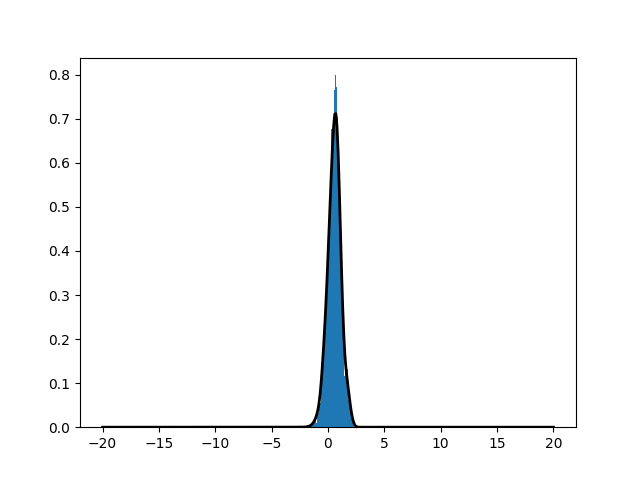

In [28]:
fig, ax = plt.subplots()

_ = ax.hist(obs_n2o, bins=np.linspace(-20,20,401), density=True)
ax.plot(x, kde_values_n2o, 'k-',linewidth=2)
mean_obs_n2o

# N<sub>2</sub>O models

## Local sensitivity of $\sigma_{\alpha}$, $\sigma_{\gamma}$, $\lambda_{\beta}$ $\lambda_{\delta}$, $\lambda_{\epsilon}$ and $\sigma_{\zeta}$

### $\sigma_{\alpha}$

In [31]:
alpha_stds = np.linspace(0.1, 5, 5)
gamma_std = 2.0
lambda_beta = 1.0
lambda_delta = 1.0
lambda_epsilon = 1.0
zeta_std = 2.0
fwhms_sigma_alpha = [[], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],]
means_sigma_alpha = [[], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],]
for i, alpha_std in enumerate(alpha_stds):
    simple_n2o, idata_simple_n2o = simple_model(T=data_n2o.T_air.values, y=data_n2o.F_N2O_ln.values,
                                                alpha_mean=0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    simple_n2o_theta, idata_simple_n2o_theta = simple_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, y=data_n2o.F_N2O_ln.values,
                                                                  alpha_mean=0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_st3, idata_full_n2o_st3 = full_model(T=data_n2o.T_air.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st4, idata_full_n2o_st4 = full_model(T=data_n2o.T_air.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st5, idata_full_n2o_st5 = full_model(T=data_n2o.T_air.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st6, idata_full_n2o_st6 = full_model(T=data_n2o.T_air.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st9, idata_full_n2o_st9 = full_model(T=data_n2o.T_air.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

    full_n2o_no_st_t_st3, idata_full_n2o_no_st_t_st3 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st4, idata_full_n2o_no_st_t_st4 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st5, idata_full_n2o_no_st_t_st5 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st6, idata_full_n2o_no_st_t_st6 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st9, idata_full_n2o_no_st_t_st9 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)

    full_n2o_theta_st3, idata_full_n2o_theta_st3 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st4, idata_full_n2o_theta_st4 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st5, idata_full_n2o_theta_st5 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st6, idata_full_n2o_theta_st6 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st9, idata_full_n2o_theta_st9 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st9, idata_full_n2o_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_simple_n2o, idata_simple_n2o_theta, idata_full_n2o_st3, idata_full_n2o_st4, idata_full_n2o_st5, idata_full_n2o_st6, idata_full_n2o_st9, idata_full_n2o_no_st_t_st3, idata_full_n2o_no_st_t_st4, idata_full_n2o_no_st_t_st5, idata_full_n2o_no_st_t_st6, idata_full_n2o_no_st_t_st9, idata_full_n2o_theta_st3,
              idata_full_n2o_theta_st4, idata_full_n2o_theta_st5, idata_full_n2o_theta_st6, idata_full_n2o_theta_st9, idata_full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st9]
    models = [simple_n2o, simple_n2o_theta, full_n2o_st3, full_n2o_st4, full_n2o_st5, full_n2o_st6, full_n2o_st9, full_n2o_no_st_t_st3, full_n2o_no_st_t_st4, full_n2o_no_st_t_st5, full_n2o_no_st_t_st6, full_n2o_no_st_t_st9, full_n2o_theta_st3,
              full_n2o_theta_st4, full_n2o_theta_st5, full_n2o_theta_st6, full_n2o_theta_st9, full_n2o_theta_no_st_t_st3, full_n2o_theta_no_st_t_st4, full_n2o_theta_no_st_t_st5, full_n2o_theta_no_st_t_st6, full_n2o_theta_no_st_t_st9]
    sts = [None, None, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o,
           st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o]
    model_name = ['simple', 'simple theta',
                  'full', 'full', 'full', 'full', 'full',
                  'full no st t', 'full no st t', 'full no st t', 'full no st t', 'full no st t',
                  'full theta', 'full theta', 'full theta', 'full theta', 'full theta',
                  'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']

        if sts[j] is None:
            data_inds = np.random.choice(
                simple_n2o['T_air'].eval().shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'simple':
                prior_values = simple_model_eq(models[j]['T_air'].eval(
                ), pp, data_inds)
            elif model_name[j] == 'simple theta':
                prior_values = simple_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), pp, data_inds)
        else:
            data_inds = np.random.choice(sts[j].shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'full':
                prior_values = full_model_eq(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full no st t':
                prior_values = full_model_eq_no_st_t(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta':
                prior_values = full_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta no st t':
                prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
            prior_values.reshape(-1, 1))
        x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_sigma_alpha[j].append(fwhm_temp)
        means_sigma_alpha[j].append(mean_temp)

Sampling: [alpha, beta, obs, sigma]
Sampling: [alpha, beta, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gam

Text(0, 0.5, 'Mean of prior predicitive distribution')

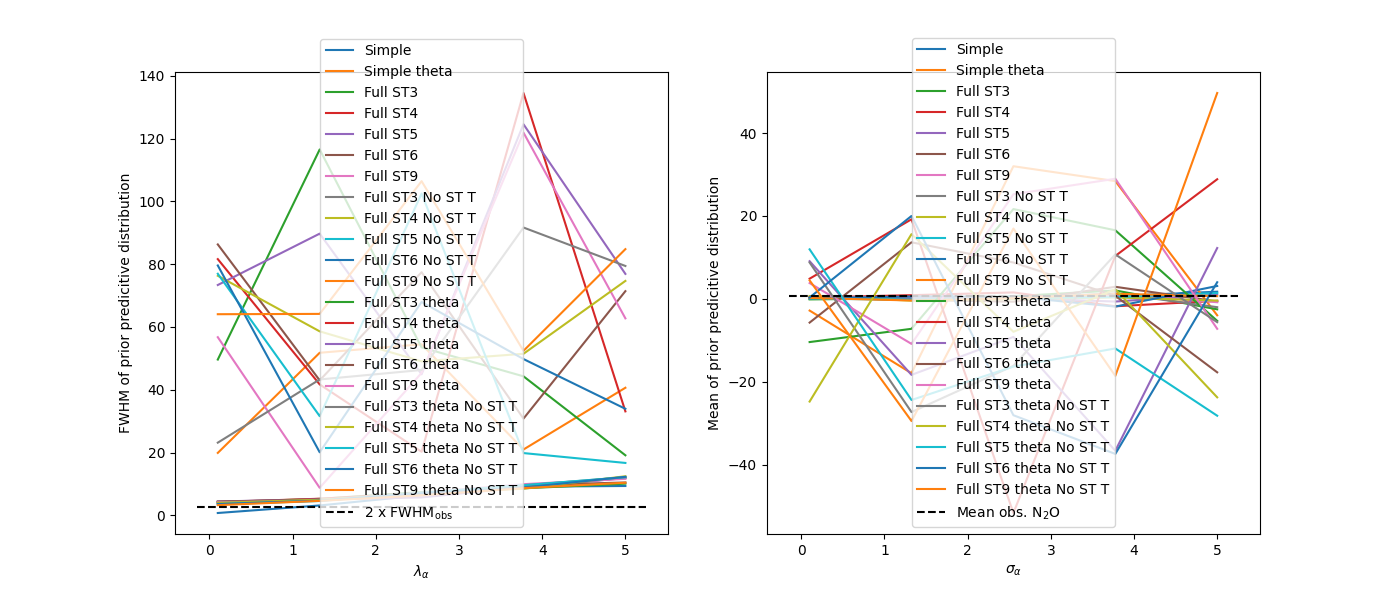

In [32]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()

labels = ['Simple', 'Simple theta',
          'Full ST3','Full ST4','Full ST5', 'Full ST6','Full ST9',
          'Full ST3 No ST T','Full ST4 No ST T','Full ST5 No ST T', 'Full ST6 No ST T','Full ST9 No ST T',
          'Full ST3 theta','Full ST4 theta','Full ST5 theta', 'Full ST6 theta','Full ST9 theta',
          'Full ST3 theta No ST T','Full ST4 theta No ST T','Full ST5 theta No ST T', 'Full ST6 theta No ST T','Full ST9 theta No ST T']
for i in range(len(labels)):
    axs[0].plot(alpha_stds, fwhms_sigma_alpha[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_n2o, 2*fwhm_obs_n2o), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel(r'$\lambda_{\alpha}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')

for i in range(len(labels)):
    axs[1].plot(alpha_stds, means_sigma_alpha[i], label=labels[i])

xlims = axs[1].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_n2o, mean_obs_n2o), 'k--', label='Mean obs. N$_2$O')
axs[1].legend()
axs[1].set_xlabel(r'$\sigma_{\alpha}$')
axs[1].set_ylabel('Mean of prior predicitive distribution')

### $\sigma_{\gamma}$

In [191]:
alpha_std = 2.0
gamma_stds = np.linspace(0.1,5,5)
lambda_beta = 1.0
lambda_delta = 1.0
lambda_epsilon = 1.0
zeta_std = 2.0
fwhms_gamma_std = [[], [], [], [], [],
                   [], [], [], [], [],
                   [], [], [], [], [],
                   [], [], [], [], [],]
mean_gamma_std = [[], [], [], [], [],
                  [], [], [], [], [],
                  [], [], [], [], [],
                  [], [], [], [], [],]
for i, gamma_std in enumerate(gamma_stds):
    full_n2o_st3, idata_full_n2o_st3 = full_model(T=data_n2o.T_air.values, X=st_3_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st4, idata_full_n2o_st4 = full_model(T=data_n2o.T_air.values, X=st_4_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st5, idata_full_n2o_st5 = full_model(T=data_n2o.T_air.values, X=st_5_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st6, idata_full_n2o_st6 = full_model(T=data_n2o.T_air.values, X=st_6_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st9, idata_full_n2o_st9 = full_model(T=data_n2o.T_air.values, X=st_9_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

    full_n2o_no_st_t_st3, idata_full_n2o_no_st_t_st3 = full_model_no_st_t(T=data_n2o.T_air.values, X=st_3_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st4, idata_full_n2o_no_st_t_st4 = full_model_no_st_t(T=data_n2o.T_air.values, X=st_4_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st5, idata_full_n2o_no_st_t_st5 = full_model_no_st_t(T=data_n2o.T_air.values, X=st_5_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st6, idata_full_n2o_no_st_t_st6 = full_model_no_st_t(T=data_n2o.T_air.values, X=st_6_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st9, idata_full_n2o_no_st_t_st9 = full_model_no_st_t(T=data_n2o.T_air.values, X=st_9_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)

    full_n2o_theta_st3, idata_full_n2o_theta_st3 = full_model_theta(T=data_n2o.T_air.values,theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st4, idata_full_n2o_theta_st4 = full_model_theta(T=data_n2o.T_air.values,theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st5, idata_full_n2o_theta_st5 = full_model_theta(T=data_n2o.T_air.values,theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st6, idata_full_n2o_theta_st6 = full_model_theta(T=data_n2o.T_air.values,theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st9, idata_full_n2o_theta_st9 = full_model_theta(T=data_n2o.T_air.values,theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_n2o.T_air.values,theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_n2o.T_air.values,theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_n2o.T_air.values,theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_n2o.T_air.values,theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st9, idata_full_n2o_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_n2o.T_air.values,theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o, y = data_n2o.F_N2O_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_full_n2o_st3, idata_full_n2o_st4, idata_full_n2o_st5, idata_full_n2o_st6, idata_full_n2o_st9, idata_full_n2o_no_st_t_st3, idata_full_n2o_no_st_t_st4, idata_full_n2o_no_st_t_st5, idata_full_n2o_no_st_t_st6, idata_full_n2o_no_st_t_st9, idata_full_n2o_theta_st3, idata_full_n2o_theta_st4, idata_full_n2o_theta_st5, idata_full_n2o_theta_st6, idata_full_n2o_theta_st9, idata_full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st9]
    models = [full_n2o_st3, full_n2o_st4, full_n2o_st5, full_n2o_st6, full_n2o_st9, full_n2o_no_st_t_st3, full_n2o_no_st_t_st4, full_n2o_no_st_t_st5, full_n2o_no_st_t_st6, full_n2o_no_st_t_st9, full_n2o_theta_st3, full_n2o_theta_st4, full_n2o_theta_st5, full_n2o_theta_st6, full_n2o_theta_st9, full_n2o_theta_no_st_t_st3, full_n2o_theta_no_st_t_st4, full_n2o_theta_no_st_t_st5, full_n2o_theta_no_st_t_st6, full_n2o_theta_no_st_t_st9]
    sts = [st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o]
    model_name = ['full','full','full','full','full',
                     'full no st t', 'full no st t','full no st t','full no st t','full no st t',
                     'full theta','full theta', 'full theta','full theta','full theta',
                     'full theta no st t','full theta no st t','full theta no st t', 'full theta no st t','full theta no st t',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']
        data_inds = np.random.choice(sts[j].shape[0], size=2000)
        pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
        if model_name[j] == 'full':
            prior_values = full_model_eq(models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
        elif model_name[j] == 'full no st t':
            prior_values = full_model_eq_no_st_t(models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
        elif model_name[j] == 'full theta':
            prior_values = full_model_eq_theta(models[j]['T_air'].eval(),models[j]['theta'].eval(), sts[j].values, pp, data_inds)
        elif model_name[j] == 'full theta no st t':
            prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(),models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(prior_values.reshape(-1, 1))
        x = np.linspace(-100,100,10001).reshape(-1,1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_gamma_std[j].append(fwhm_temp)
        mean_gamma_std[j].append(mean_temp)


Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, 

/var/folders/_7/7fgf24sd5ggbyr5x9kzrwz7c0000gn/T/ipykernel_32649/66405930.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(figsize=(14,6), ncols=2)


Text(0, 0.5, 'Mean of prior distribution')

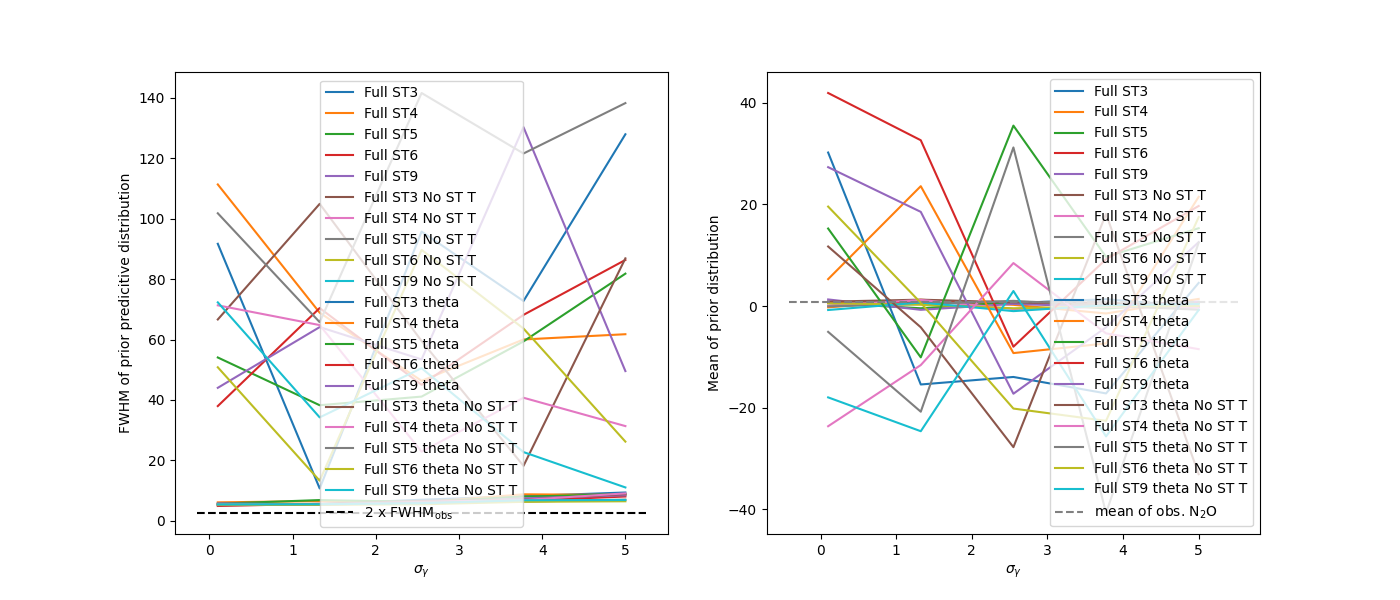

In [192]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()
labels = ['Full ST3','Full ST4','Full ST5', 'Full ST6','Full ST9',
          'Full ST3 No ST T','Full ST4 No ST T','Full ST5 No ST T', 'Full ST6 No ST T','Full ST9 No ST T',
          'Full ST3 theta','Full ST4 theta','Full ST5 theta', 'Full ST6 theta','Full ST9 theta',
          'Full ST3 theta No ST T','Full ST4 theta No ST T','Full ST5 theta No ST T', 'Full ST6 theta No ST T','Full ST9 theta No ST T']
for i in range(20):
    axs[0].plot(gamma_stds, fwhms_gamma_std[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_n2o, 2*fwhm_obs_n2o), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel('$\sigma_{\gamma}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')


for i in range(20):
    axs[1].plot(gamma_stds, mean_gamma_std[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_n2o, mean_obs_n2o), '--', color='gray', label='mean of obs. N$_2$O')
axs[1].legend()
axs[1].set_xlabel('$\sigma_{\gamma}$')
axs[1].set_ylabel('Mean of prior distribution')

### $\lambda_{\beta}$

In [193]:
alpha_std = 2.0
gamma_std = 2.0  # np.linspace(0.1,5,11)
lambda_betas = np.linspace(0.1, 5, 5)
lambda_delta = 1.0
lambda_epsilon = 1.0
zeta_std = 2.0
fwhms_lambda_beta = [[], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],]
means_lambda_beta = [[], [],
                    [], [], [], [], [],
                    [], [], [], [], [],
                    [], [], [], [], [],
                    [], [], [], [], [],]
for i, lambda_beta in enumerate(lambda_betas):
    simple_n2o, idata_simple_n2o = simple_model(T=data_n2o.T_air.values, y=data_n2o.F_N2O_ln.values,
                                                alpha_mean=0.0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    simple_n2o_theta, idata_simple_n2o_theta = simple_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, y=data_n2o.F_N2O_ln.values,
                                                                  alpha_mean=0.0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_st3, idata_full_n2o_st3 = full_model(T=data_n2o.T_air.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st4, idata_full_n2o_st4 = full_model(T=data_n2o.T_air.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st5, idata_full_n2o_st5 = full_model(T=data_n2o.T_air.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st6, idata_full_n2o_st6 = full_model(T=data_n2o.T_air.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st9, idata_full_n2o_st9 = full_model(T=data_n2o.T_air.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

    full_n2o_no_st_t_st3, idata_full_n2o_no_st_t_st3 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st4, idata_full_n2o_no_st_t_st4 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st5, idata_full_n2o_no_st_t_st5 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st6, idata_full_n2o_no_st_t_st6 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st9, idata_full_n2o_no_st_t_st9 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)

    full_n2o_theta_st3, idata_full_n2o_theta_st3 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st4, idata_full_n2o_theta_st4 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st5, idata_full_n2o_theta_st5 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st6, idata_full_n2o_theta_st6 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st9, idata_full_n2o_theta_st9 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st9, idata_full_n2o_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_simple_n2o, idata_simple_n2o_theta, idata_full_n2o_st3, idata_full_n2o_st4, idata_full_n2o_st5, idata_full_n2o_st6, idata_full_n2o_st9, idata_full_n2o_no_st_t_st3, idata_full_n2o_no_st_t_st4, idata_full_n2o_no_st_t_st5, idata_full_n2o_no_st_t_st6, idata_full_n2o_no_st_t_st9, idata_full_n2o_theta_st3,
              idata_full_n2o_theta_st4, idata_full_n2o_theta_st5, idata_full_n2o_theta_st6, idata_full_n2o_theta_st9, idata_full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st9]
    models = [simple_n2o, simple_n2o_theta, full_n2o_st3, full_n2o_st4, full_n2o_st5, full_n2o_st6, full_n2o_st9, full_n2o_no_st_t_st3, full_n2o_no_st_t_st4, full_n2o_no_st_t_st5, full_n2o_no_st_t_st6, full_n2o_no_st_t_st9, full_n2o_theta_st3,
              full_n2o_theta_st4, full_n2o_theta_st5, full_n2o_theta_st6, full_n2o_theta_st9, full_n2o_theta_no_st_t_st3, full_n2o_theta_no_st_t_st4, full_n2o_theta_no_st_t_st5, full_n2o_theta_no_st_t_st6, full_n2o_theta_no_st_t_st9]
    sts = [None, None, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o,
           st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o]
    model_name = ['simple', 'simple theta',
                  'full', 'full', 'full', 'full', 'full',
                  'full no st t', 'full no st t', 'full no st t', 'full no st t', 'full no st t',
                  'full theta', 'full theta', 'full theta', 'full theta', 'full theta',
                  'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']

        if sts[j] is None:
            data_inds = np.random.choice(
                simple_n2o['T_air'].eval().shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'simple':
                prior_values = simple_model_eq(models[j]['T_air'].eval(
                ), pp, data_inds)
            elif model_name[j] == 'simple theta':
                prior_values = simple_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), pp, data_inds)
        else:
            data_inds = np.random.choice(sts[j].shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'full':
                prior_values = full_model_eq(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full no st t':
                prior_values = full_model_eq_no_st_t(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta':
                prior_values = full_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta no st t':
                prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
            prior_values.reshape(-1, 1))
        x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_lambda_beta[j].append(fwhm_temp)
        means_lambda_beta[j].append(mean_temp)

Sampling: [alpha, beta, obs, sigma]
Sampling: [alpha, beta, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gam

Text(0, 0.5, 'Mean of prior predicitive distribution')

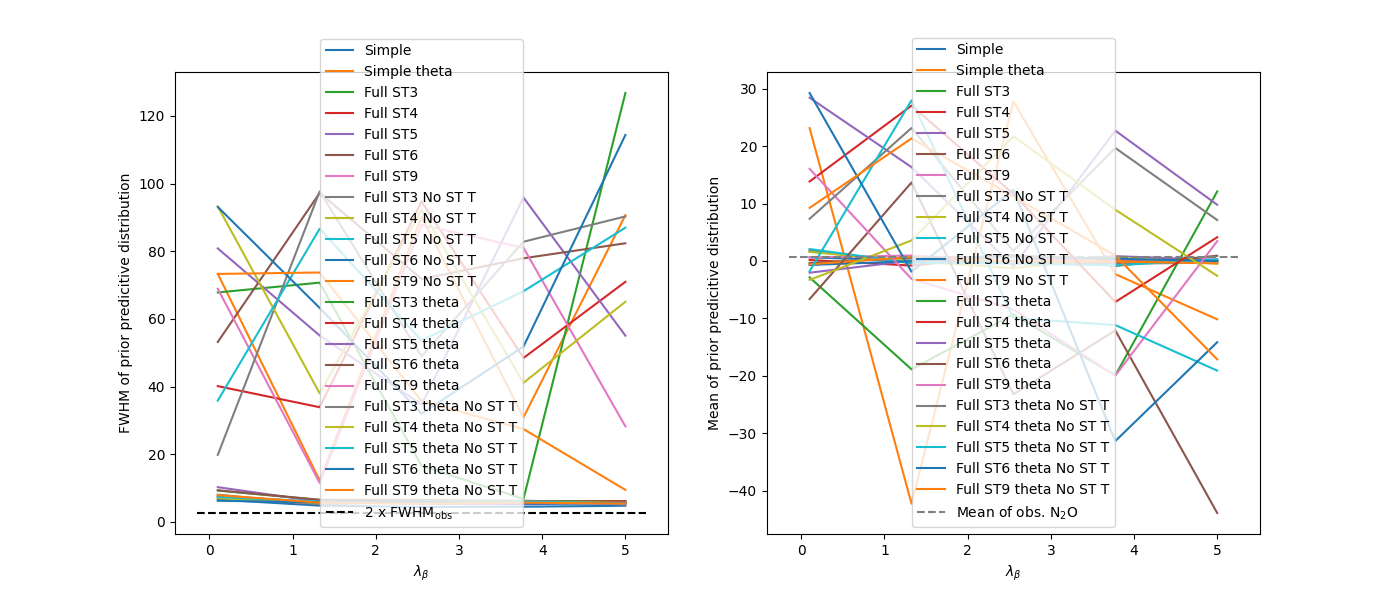

In [194]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()
labels = ['Simple', 'Simple theta',
          'Full ST3','Full ST4','Full ST5', 'Full ST6','Full ST9',
          'Full ST3 No ST T','Full ST4 No ST T','Full ST5 No ST T', 'Full ST6 No ST T','Full ST9 No ST T',
          'Full ST3 theta','Full ST4 theta','Full ST5 theta', 'Full ST6 theta','Full ST9 theta',
          'Full ST3 theta No ST T','Full ST4 theta No ST T','Full ST5 theta No ST T', 'Full ST6 theta No ST T','Full ST9 theta No ST T']
for i in range(len(labels)):
    axs[0].plot(lambda_betas, fwhms_lambda_beta[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_n2o, 2*fwhm_obs_n2o), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel(r'$\lambda_{\beta}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')


for i in range(len(labels)):
    axs[1].plot(lambda_betas, means_lambda_beta[i], label=labels[i])

xlims = axs[1].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_n2o, mean_obs_n2o), '--', color='gray', label='Mean of obs. N$_2$O')
axs[1].legend()
axs[1].set_xlabel(r'$\lambda_{\beta}$')
axs[1].set_ylabel('Mean of prior predicitive distribution')

### $\lambda_{\delta}$

In [195]:
alpha_std = 2.0
gamma_std = 2.0
lambda_beta = 1.0
lambda_deltas = np.linspace(0.1, 5, 5)
lambda_epsilon = 1.0
zeta_std = 2.0
fwhms_lambda_delta = [
                     [], [], [], [], [],
                     [], [], [], [], [],]
means_lambda_delta = [
                    [], [], [], [], [],
                    [], [], [], [], [],]
for i, lambda_delta in enumerate(lambda_deltas):

    full_n2o_st3, idata_full_n2o_st3 = full_model(T=data_n2o.T_air.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st4, idata_full_n2o_st4 = full_model(T=data_n2o.T_air.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st5, idata_full_n2o_st5 = full_model(T=data_n2o.T_air.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st6, idata_full_n2o_st6 = full_model(T=data_n2o.T_air.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st9, idata_full_n2o_st9 = full_model(T=data_n2o.T_air.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

    full_n2o_theta_st3, idata_full_n2o_theta_st3 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st4, idata_full_n2o_theta_st4 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st5, idata_full_n2o_theta_st5 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st6, idata_full_n2o_theta_st6 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st9, idata_full_n2o_theta_st9 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_full_n2o_st3, idata_full_n2o_st4, idata_full_n2o_st5, idata_full_n2o_st6, idata_full_n2o_st9, idata_full_n2o_theta_st3,
              idata_full_n2o_theta_st4, idata_full_n2o_theta_st5, idata_full_n2o_theta_st6, idata_full_n2o_theta_st9,]
    models = [full_n2o_st3, full_n2o_st4, full_n2o_st5, full_n2o_st6, full_n2o_st9, full_n2o_theta_st3,
              full_n2o_theta_st4, full_n2o_theta_st5, full_n2o_theta_st6, full_n2o_theta_st9,]
    sts = [st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o]
    model_name = [
                  'full', 'full', 'full', 'full', 'full',
                  'full theta', 'full theta', 'full theta', 'full theta', 'full theta',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']

        if sts[j] is None:
            data_inds = np.random.choice(
                simple_n2o['T_air'].eval().shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'simple':
                prior_values = simple_model_eq(models[j]['T_air'].eval(
                ), pp, data_inds)
            elif model_name[j] == 'simple theta':
                prior_values = simple_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), pp, data_inds)
        else:
            data_inds = np.random.choice(sts[j].shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'full':
                prior_values = full_model_eq(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full no st t':
                prior_values = full_model_eq_no_st_t(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta':
                prior_values = full_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta no st t':
                prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
            prior_values.reshape(-1, 1))
        x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_lambda_delta[j].append(fwhm_temp)
        means_lambda_delta[j].append(mean_temp)


Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Samp

Text(0, 0.5, 'Mean of prior predicitive distribution')

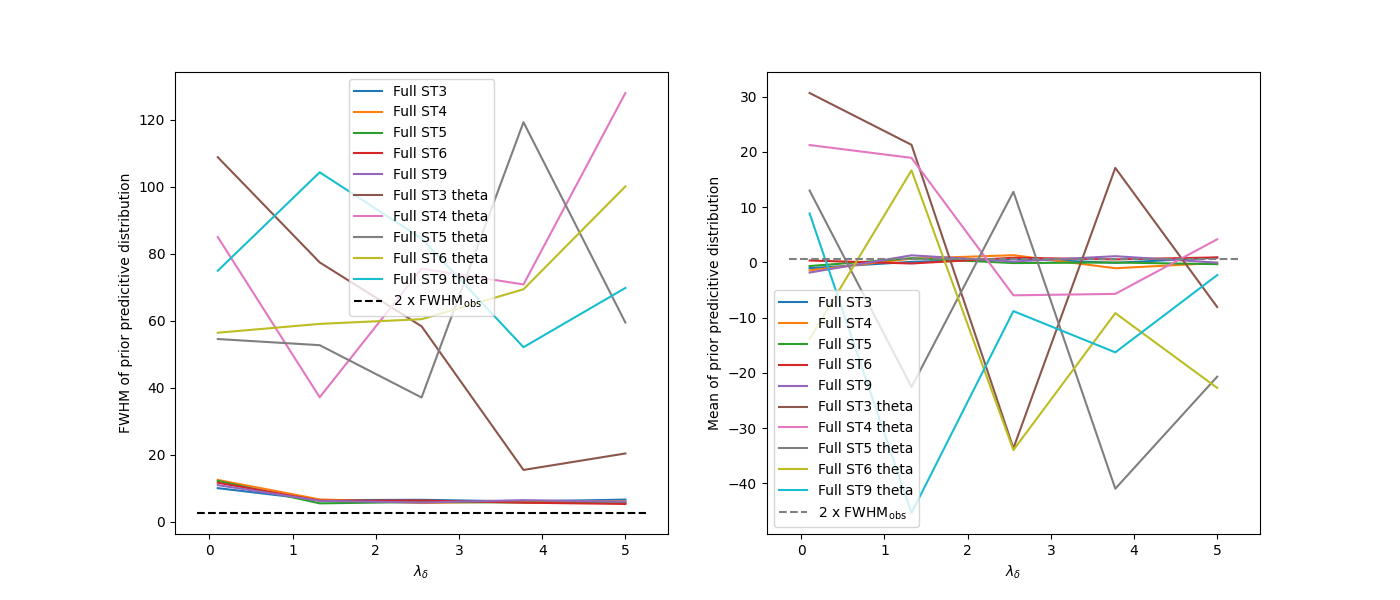

In [196]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()
labels = ['Full ST3','Full ST4','Full ST5','Full ST6','Full ST9', 'Full ST3 theta','Full ST4 theta','Full ST5 theta','Full ST6 theta','Full ST9 theta']
for i in range(len(labels)):
    axs[0].plot(lambda_deltas, fwhms_lambda_delta[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_n2o, 2*fwhm_obs_n2o), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel(r'$\lambda_{\delta}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')

for i in range(len(labels)):
    axs[1].plot(lambda_deltas, means_lambda_delta[i], label=labels[i])

xlims = axs[1].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_n2o, mean_obs_n2o), '--', color='gray', label='2 x FWHM$_{\mathrm{obs}}$')
axs[1].legend()
axs[1].set_xlabel(r'$\lambda_{\delta}$')
axs[1].set_ylabel('Mean of prior predicitive distribution')

### $\lambda_{\epsilon}$

In [197]:
alpha_std = 2.0
gamma_std = 2.0 #np.linspace(0.1,5,11)
lambda_beta = 1.0
lambda_delta = 1.0
lambda_epsilons = np.linspace(0.1, 5, 5)
zeta_std = 2.0
fwhms_lambda_epsilon = [[], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],]
means_lambda_epsilon = [[], [],
                    [], [], [], [], [],
                    [], [], [], [], [],
                    [], [], [], [], [],
                    [], [], [], [], [],]
for i, lambda_epsilon in enumerate(lambda_epsilons):
    simple_n2o, idata_simple_n2o = simple_model(T=data_n2o.T_air.values, y=data_n2o.F_N2O_ln.values,
                                                alpha_mean=0.0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    simple_n2o_theta, idata_simple_n2o_theta = simple_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, y=data_n2o.F_N2O_ln.values,
                                                                  alpha_mean=0.0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_st3, idata_full_n2o_st3 = full_model(T=data_n2o.T_air.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st4, idata_full_n2o_st4 = full_model(T=data_n2o.T_air.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st5, idata_full_n2o_st5 = full_model(T=data_n2o.T_air.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st6, idata_full_n2o_st6 = full_model(T=data_n2o.T_air.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_n2o_st9, idata_full_n2o_st9 = full_model(T=data_n2o.T_air.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

    full_n2o_no_st_t_st3, idata_full_n2o_no_st_t_st3 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st4, idata_full_n2o_no_st_t_st4 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st5, idata_full_n2o_no_st_t_st5 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st6, idata_full_n2o_no_st_t_st6 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_n2o_no_st_t_st9, idata_full_n2o_no_st_t_st9 = full_model_no_st_t(
        T=data_n2o.T_air.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)

    full_n2o_theta_st3, idata_full_n2o_theta_st3 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st4, idata_full_n2o_theta_st4 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st5, idata_full_n2o_theta_st5 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st6, idata_full_n2o_theta_st6 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st9, idata_full_n2o_theta_st9 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st9, idata_full_n2o_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_simple_n2o, idata_simple_n2o_theta, idata_full_n2o_st3, idata_full_n2o_st4, idata_full_n2o_st5, idata_full_n2o_st6, idata_full_n2o_st9, idata_full_n2o_no_st_t_st3, idata_full_n2o_no_st_t_st4, idata_full_n2o_no_st_t_st5, idata_full_n2o_no_st_t_st6, idata_full_n2o_no_st_t_st9, idata_full_n2o_theta_st3,
              idata_full_n2o_theta_st4, idata_full_n2o_theta_st5, idata_full_n2o_theta_st6, idata_full_n2o_theta_st9, idata_full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st9]
    models = [simple_n2o, simple_n2o_theta, full_n2o_st3, full_n2o_st4, full_n2o_st5, full_n2o_st6, full_n2o_st9, full_n2o_no_st_t_st3, full_n2o_no_st_t_st4, full_n2o_no_st_t_st5, full_n2o_no_st_t_st6, full_n2o_no_st_t_st9, full_n2o_theta_st3,
              full_n2o_theta_st4, full_n2o_theta_st5, full_n2o_theta_st6, full_n2o_theta_st9, full_n2o_theta_no_st_t_st3, full_n2o_theta_no_st_t_st4, full_n2o_theta_no_st_t_st5, full_n2o_theta_no_st_t_st6, full_n2o_theta_no_st_t_st9]
    sts = [None, None, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o,
           st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o]
    model_name = ['simple', 'simple theta',
                  'full', 'full', 'full', 'full', 'full',
                  'full no st t', 'full no st t', 'full no st t', 'full no st t', 'full no st t',
                  'full theta', 'full theta', 'full theta', 'full theta', 'full theta',
                  'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']

        if sts[j] is None:
            data_inds = np.random.choice(
                simple_n2o['T_air'].eval().shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'simple':
                prior_values = simple_model_eq(models[j]['T_air'].eval(
                ), pp, data_inds)
            elif model_name[j] == 'simple theta':
                prior_values = simple_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), pp, data_inds)
        else:
            data_inds = np.random.choice(sts[j].shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'full':
                prior_values = full_model_eq(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full no st t':
                prior_values = full_model_eq_no_st_t(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta':
                prior_values = full_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta no st t':
                prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
            prior_values.reshape(-1, 1))
        x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_lambda_epsilon[j].append(fwhm_temp)
        means_lambda_epsilon[j].append(mean_temp)


Sampling: [alpha, beta, obs, sigma]
Sampling: [alpha, beta, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gam

Text(0, 0.5, 'Mean of prior predicitive distribution')

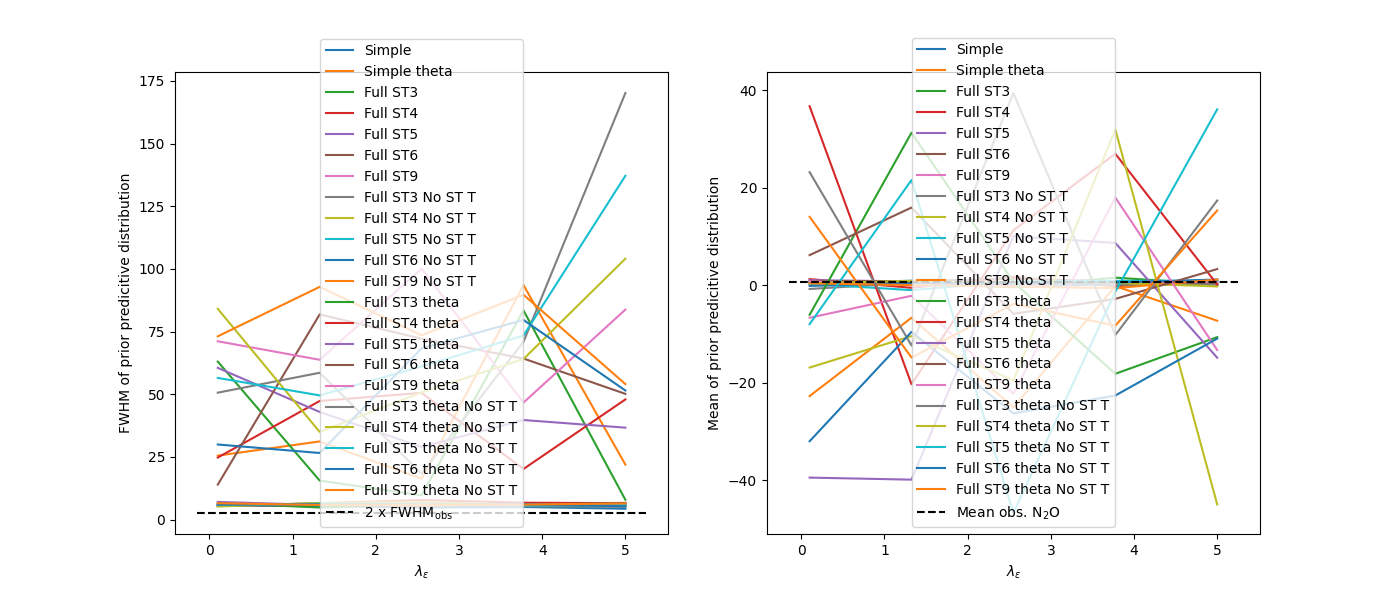

In [198]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()

labels = ['Simple', 'Simple theta',
          'Full ST3','Full ST4','Full ST5', 'Full ST6','Full ST9',
          'Full ST3 No ST T','Full ST4 No ST T','Full ST5 No ST T', 'Full ST6 No ST T','Full ST9 No ST T',
          'Full ST3 theta','Full ST4 theta','Full ST5 theta', 'Full ST6 theta','Full ST9 theta',
          'Full ST3 theta No ST T','Full ST4 theta No ST T','Full ST5 theta No ST T', 'Full ST6 theta No ST T','Full ST9 theta No ST T']
for i in range(len(labels)):
    axs[0].plot(lambda_epsilons, fwhms_lambda_epsilon[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_n2o, 2*fwhm_obs_n2o), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel(r'$\lambda_{\epsilon}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')

for i in range(len(labels)):
    axs[1].plot(lambda_epsilons, means_lambda_epsilon[i], label=labels[i])

xlims = axs[1].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_n2o, mean_obs_n2o), 'k--', label='Mean obs. N$_2$O')
axs[1].legend()
axs[1].set_xlabel(r'$\lambda_{\epsilon}$')
axs[1].set_ylabel('Mean of prior predicitive distribution')

### $\sigma_{\zeta}$

In [199]:
alpha_std = 2.0
gamma_std = 2.0
lambda_beta = 1.0
lambda_delta = 1.0
lambda_epsilons = np.linspace(0.1, 5, 5)
zeta_std = 2.0
fwhms_sigma_zeta = [
                     [], [], [], [], [],
                     [], [], [], [], [],]
means_sigma_zeta = [
                    [], [], [], [], [],
                    [], [], [], [], [],]
for i, lambda_epsilon in enumerate(lambda_epsilons):
    full_n2o_theta_st3, idata_full_n2o_theta_st3 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st4, idata_full_n2o_theta_st4 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st5, idata_full_n2o_theta_st5 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st6, idata_full_n2o_theta_st6 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_st9, idata_full_n2o_theta_st9 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_n2o_theta_no_st_t_st9, idata_full_n2o_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o,
                                                                                            y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_full_n2o_theta_st3,
              idata_full_n2o_theta_st4, idata_full_n2o_theta_st5, idata_full_n2o_theta_st6, idata_full_n2o_theta_st9, idata_full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st9]
    models = [full_n2o_theta_st3,
              full_n2o_theta_st4, full_n2o_theta_st5, full_n2o_theta_st6, full_n2o_theta_st9, full_n2o_theta_no_st_t_st3, full_n2o_theta_no_st_t_st4, full_n2o_theta_no_st_t_st5, full_n2o_theta_no_st_t_st6, full_n2o_theta_no_st_t_st9]
    sts = [
           st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o]
    model_name = [
                  'full theta', 'full theta', 'full theta', 'full theta', 'full theta',
                  'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']

        if sts[j] is None:
            data_inds = np.random.choice(
                simple_n2o['T_air'].eval().shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'simple':
                prior_values = simple_model_eq(models[j]['T_air'].eval(
                ), pp, data_inds)
            elif model_name[j] == 'simple theta':
                prior_values = simple_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), pp, data_inds)
        else:
            data_inds = np.random.choice(sts[j].shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'full':
                prior_values = full_model_eq(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full no st t':
                prior_values = full_model_eq_no_st_t(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta':
                prior_values = full_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta no st t':
                prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
            prior_values.reshape(-1, 1))
        x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_sigma_zeta[j].append(fwhm_temp)
        means_sigma_zeta[j].append(mean_temp)


Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs,

Text(0, 0.5, 'Mean of prior predicitive distribution')

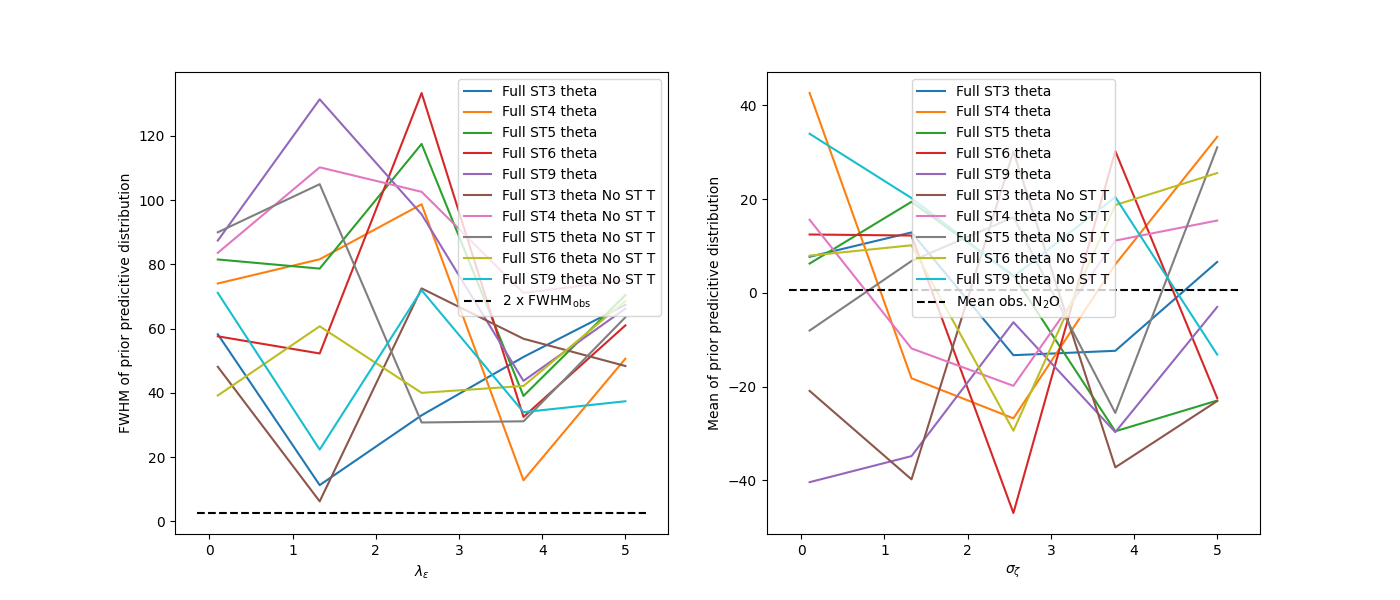

In [200]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()

labels = [
          'Full ST3 theta','Full ST4 theta','Full ST5 theta', 'Full ST6 theta','Full ST9 theta',
          'Full ST3 theta No ST T','Full ST4 theta No ST T','Full ST5 theta No ST T', 'Full ST6 theta No ST T','Full ST9 theta No ST T']
for i in range(len(labels)):
    axs[0].plot(lambda_epsilons, fwhms_sigma_zeta[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_n2o, 2*fwhm_obs_n2o), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel(r'$\lambda_{\epsilon}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')

for i in range(len(labels)):
    axs[1].plot(lambda_epsilons, means_sigma_zeta[i], label=labels[i])

xlims = axs[1].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_n2o, mean_obs_n2o), 'k--', label='Mean obs. N$_2$O')
axs[1].legend()
axs[1].set_xlabel(r'$\sigma_{\zeta}$')
axs[1].set_ylabel('Mean of prior predicitive distribution')

## Choose values
These values are used in the notebook [GHG_models_fit.ipynb](GHG_models_fit.ipynb)
$$
\begin{align*}
\sigma_\alpha = 2.0 \\
\sigma_\gamma = 2.0 \\
\sigma_\zeta = 2.0 \\
\lambda_\beta = 1.0 \\
\lambda_\delta = 1.0 \\
\lambda_\epsilon = 1.0 \\

\end{align*}
$$

## Plot prior predicitive distributions

In [22]:
def plot_prior_predictive(obs, prior_values, xlabel, ax, title=''):
    fs=16
    ls=14
    bins, counts, _ = ax.hist(obs, bins=100, color='goldenrod', density=True, label=f'Measured {xlabel}')
    bins, counts, _ = ax.hist(prior_values, bins = np.linspace(-100,100,10001), alpha=0.75, density=True, label='Prior')

    #ax.legend(loc='best')
    ax.tick_params(axis='both', labelsize=ls)
    ax.set_title(title, fontsize=fs)

    kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(obs.reshape(-1, 1))
    x = np.linspace(-100,100,10001).reshape(-1,1)
    kde_values = np.exp(kde.score_samples(x))
    fwhm_obs, mean_obs = FWHM(x, kde_values)


    obs_max_x = x[np.argmax(kde_values)]
    xmax = obs_max_x + 5*fwhm_obs
    xmin = obs_max_x - 5*fwhm_obs
    ax.set_xlim([xmin, xmax])

    kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(prior_values.reshape(-1, 1))
    kde_values = np.exp(kde.score_samples(x))
    fwhm_model, mean_model = FWHM(x, kde_values)

    # ymin, ymax = ax.get_ylim()
    # xmin, xmax = ax.get_xlim()
    ax.text(0.05, 0.75, f'FWHM$_{{\mathrm{{model}}}}: {np.round(fwhm_model,2)}$', transform=ax.transAxes)
    ax.text(0.05, 0.65, f'FWHM$_{{\mathrm{{obs}}}}: {np.round(fwhm_obs,2)}$', transform=ax.transAxes)
    ax.text(0.05, 0.55, f'$\mu_{{\mathrm{{model}}}}: {np.round(mean_model,2)}$',transform=ax.transAxes)
    ax.text(0.05, 0.45, f'$\mu_{{\mathrm{{obs}}}}: {np.round(mean_obs,2)}$', transform=ax.transAxes)

    ax.set_yticks([])


Sampling: [alpha, beta, obs, sigma]
Sampling: [alpha, beta, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gam

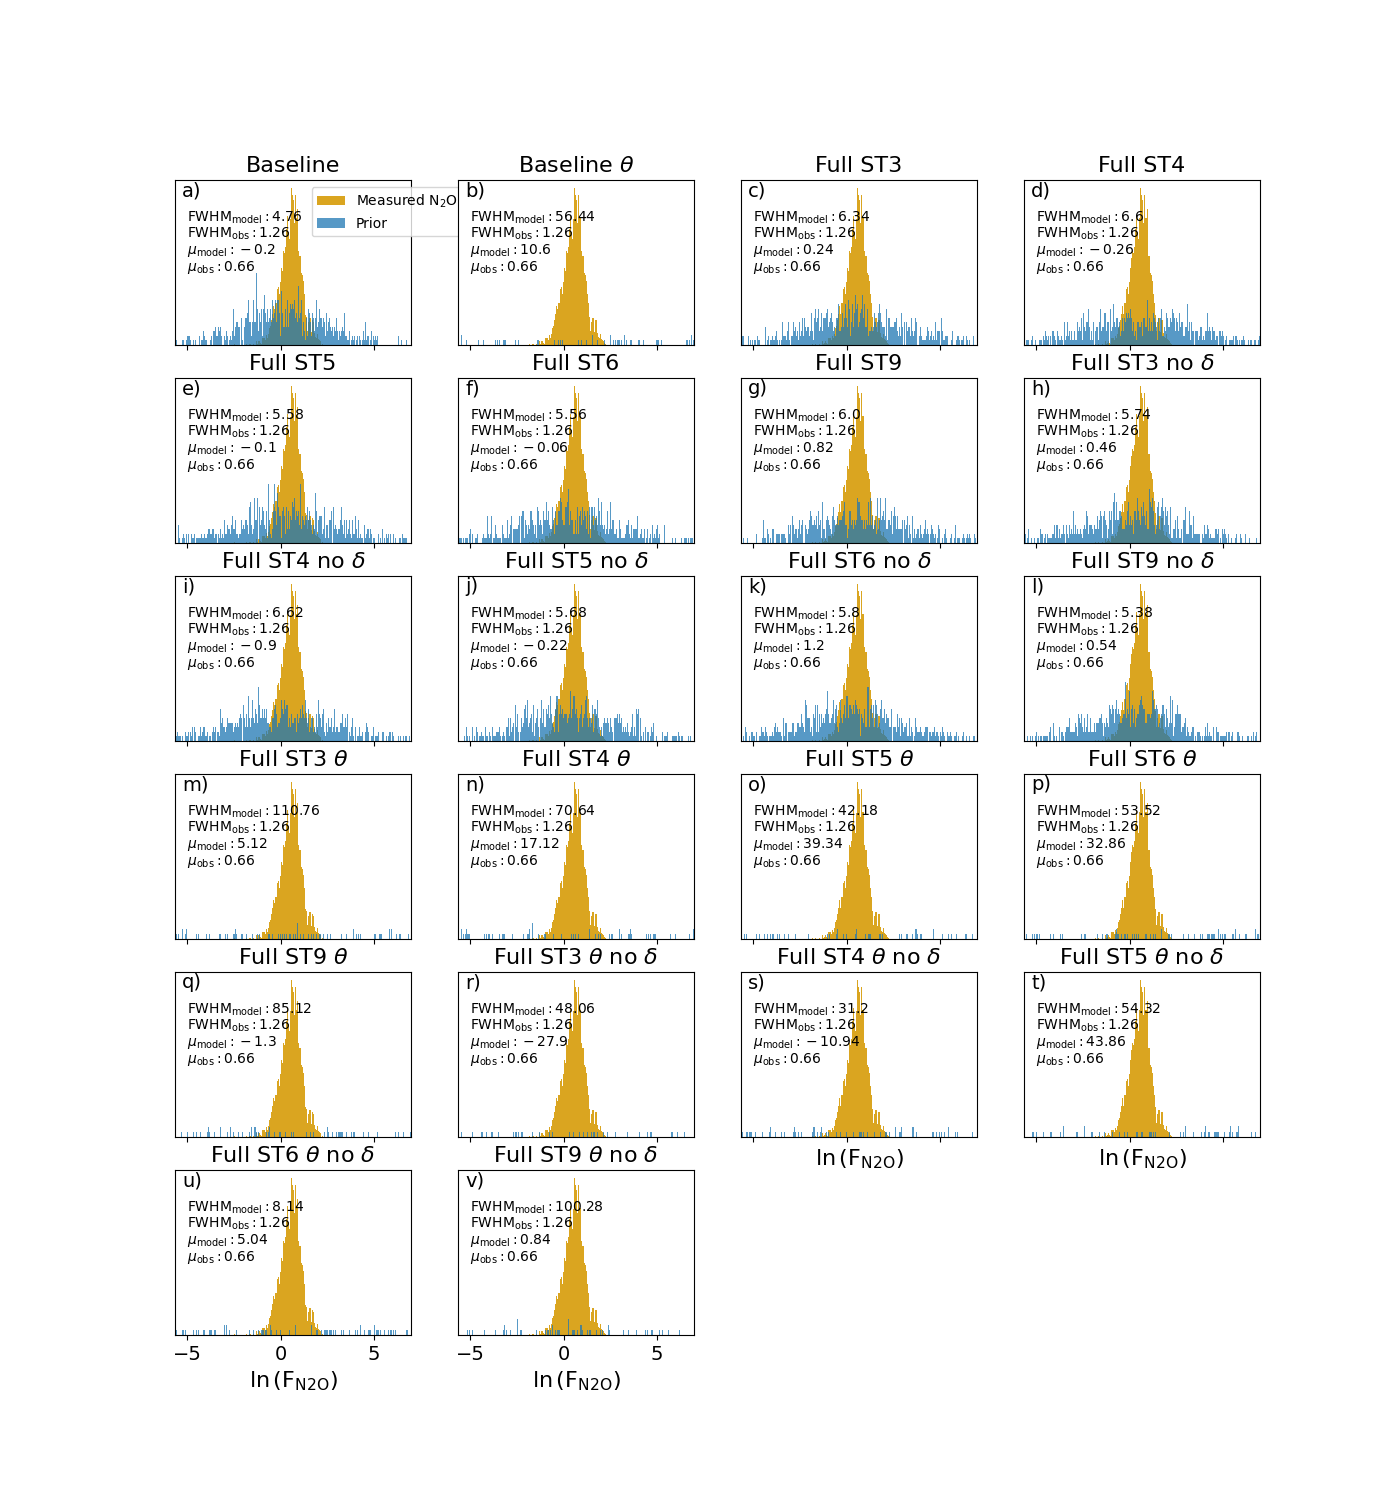

In [23]:
fig, axs = plt.subplots(figsize=(14, 15), nrows=6,
                        ncols=4, sharex=True, sharey=True)
axs = axs.flatten()
sigma_alpha = 2.0
sigma_zeta = 2.0
sigma_gamma = 2.0
lambda_beta = 1.0
lambda_delta = 1.0
lambda_epsilon = 1.0

simple_n2o, idata_simple_n2o = simple_model(T=data_n2o.T_air.values, y=data_n2o.F_N2O_ln.values,
                                            alpha_mean=0.0, alpha_std=sigma_alpha,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
simple_n2o_theta, idata_simple_n2o_theta = simple_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, y=data_n2o.F_N2O_ln.values,
                                                              alpha_mean=0.0, alpha_std=sigma_alpha,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_n2o_st3, idata_full_n2o_st3 = full_model(T=data_n2o.T_air.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                              alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
full_n2o_st4, idata_full_n2o_st4 = full_model(T=data_n2o.T_air.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                              alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
full_n2o_st5, idata_full_n2o_st5 = full_model(T=data_n2o.T_air.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                              alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
full_n2o_st6, idata_full_n2o_st6 = full_model(T=data_n2o.T_air.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                              alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
full_n2o_st9, idata_full_n2o_st9 = full_model(T=data_n2o.T_air.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0,
                                              alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

full_n2o_no_st_t_st3, idata_full_n2o_no_st_t_st3 = full_model_no_st_t(
    T=data_n2o.T_air.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
full_n2o_no_st_t_st4, idata_full_n2o_no_st_t_st4 = full_model_no_st_t(
    T=data_n2o.T_air.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
full_n2o_no_st_t_st5, idata_full_n2o_no_st_t_st5 = full_model_no_st_t(
    T=data_n2o.T_air.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
full_n2o_no_st_t_st6, idata_full_n2o_no_st_t_st6 = full_model_no_st_t(
    T=data_n2o.T_air.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
full_n2o_no_st_t_st9, idata_full_n2o_no_st_t_st9 = full_model_no_st_t(
    T=data_n2o.T_air.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)

full_n2o_theta_st3, idata_full_n2o_theta_st3 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o, y=data_n2o.F_N2O_ln.values,
                                                                alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_n2o_theta_st4, idata_full_n2o_theta_st4 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o, y=data_n2o.F_N2O_ln.values,
                                                                alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_n2o_theta_st5, idata_full_n2o_theta_st5 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o, y=data_n2o.F_N2O_ln.values,
                                                                alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_n2o_theta_st6, idata_full_n2o_theta_st6 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o, y=data_n2o.F_N2O_ln.values,
                                                                alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_n2o_theta_st9, idata_full_n2o_theta_st9 = full_model_theta(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o, y=data_n2o.F_N2O_ln.values,
                                                                alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)

full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_3_n2o,
                                                                                        y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_4_n2o,
                                                                                        y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_5_n2o,
                                                                                        y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_6_n2o,
                                                                                        y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_n2o_theta_no_st_t_st9, idata_full_n2o_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_n2o.T_air.values, theta=data_n2o.soil_moisture_tomst_mean.values, X=st_9_n2o,
                                                                                        y=data_n2o.F_N2O_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)

idatas = [idata_simple_n2o, idata_simple_n2o_theta, idata_full_n2o_st3, idata_full_n2o_st4, idata_full_n2o_st5, idata_full_n2o_st6, idata_full_n2o_st9, idata_full_n2o_no_st_t_st3, idata_full_n2o_no_st_t_st4, idata_full_n2o_no_st_t_st5, idata_full_n2o_no_st_t_st6, idata_full_n2o_no_st_t_st9, idata_full_n2o_theta_st3,
          idata_full_n2o_theta_st4, idata_full_n2o_theta_st5, idata_full_n2o_theta_st6, idata_full_n2o_theta_st9, idata_full_n2o_theta_no_st_t_st3, idata_full_n2o_theta_no_st_t_st4, idata_full_n2o_theta_no_st_t_st5, idata_full_n2o_theta_no_st_t_st6, idata_full_n2o_theta_no_st_t_st9]
models = [simple_n2o, simple_n2o_theta, full_n2o_st3, full_n2o_st4, full_n2o_st5, full_n2o_st6, full_n2o_st9, full_n2o_no_st_t_st3, full_n2o_no_st_t_st4, full_n2o_no_st_t_st5, full_n2o_no_st_t_st6, full_n2o_no_st_t_st9, full_n2o_theta_st3,
          full_n2o_theta_st4, full_n2o_theta_st5, full_n2o_theta_st6, full_n2o_theta_st9, full_n2o_theta_no_st_t_st3, full_n2o_theta_no_st_t_st4, full_n2o_theta_no_st_t_st5, full_n2o_theta_no_st_t_st6, full_n2o_theta_no_st_t_st9]
sts = [None, None, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o,
       st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o, st_3_n2o, st_4_n2o, st_5_n2o, st_6_n2o, st_9_n2o]
model_name = ['simple', 'simple theta',
              'full', 'full', 'full', 'full', 'full',
              'full no st t', 'full no st t', 'full no st t', 'full no st t', 'full no st t',
              'full theta', 'full theta', 'full theta', 'full theta', 'full theta',
              'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t',]

titles = [r'Baseline',r'Baseline $\theta$', r'Full ST3', r'Full ST4', r'Full ST5', r'Full ST6', r'Full ST9',
          r'Full ST3 no $\delta$', r'Full ST4 no $\delta$', r'Full ST5 no $\delta$', r'Full ST6 no $\delta$', r'Full ST9 no $\delta$',
          r'Full ST3 $\theta$', r'Full ST4 $\theta$', r'Full ST5 $\theta$', r'Full ST6 $\theta$', r'Full ST9 $\theta$',
          r'Full ST3 $\theta$ no $\delta$', r'Full ST4 $\theta$ no $\delta$', r'Full ST5 $\theta$ no $\delta$', r'Full ST6 $\theta$ no $\delta$', r'Full ST9 $\theta$ no $\delta$',]
subplot_labels = ['a)', 'b)', 
                  'c)', 'd)', 'e)', 'f)' ,'g)','h)',
                  'i)', 'j)', 'k)', 'l)' ,'m)','n)',
                  'o)', 'p)', 'q)', 'r)' ,'s)','t)',
                  'u)', 'v)', 'w)', 'x)' ,'y)','z)',]
for i, idata in enumerate(idatas):
    prior = idata['prior']
    if sts[i] is None:
        data_inds = np.random.choice(
            simple_n2o['T_air'].eval().shape[0], size=2000)
        pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
        if model_name[i] == 'simple':
            prior_values = simple_model_eq(models[i]['T_air'].eval(
            ), pp, data_inds)
        elif model_name[i] == 'simple theta':
            prior_values = simple_model_eq_theta(models[i]['T_air'].eval(
            ), models[i]['theta'].eval(), pp, data_inds)
    else:
        data_inds = np.random.choice(sts[i].shape[0], size=2000)
        pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
        if model_name[i] == 'full':
            prior_values = full_model_eq(
                models[i]['T_air'].eval(), sts[i].values, pp, data_inds)
        elif model_name[i] == 'full no st t':
            prior_values = full_model_eq_no_st_t(
                models[i]['T_air'].eval(), sts[i].values, pp, data_inds)
        elif model_name[i] == 'full theta':
            prior_values = full_model_eq_theta(models[i]['T_air'].eval(
            ), models[i]['theta'].eval(), sts[i].values, pp, data_inds)
        elif model_name[i] == 'full theta no st t':
            prior_values = full_model_eq_theta_no_st_t(models[i]['T_air'].eval(
            ), models[i]['theta'].eval(), sts[i].values, pp, data_inds)

        # kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
        #     prior_values.reshape(-1, 1))
        # x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        # kde_values = np.exp(kde.score_samples(x))
        # fwhm_temp, mean_temp = FWHM(x, kde_values)
        # fwhms_lambda_epsilon[j].append(fwhm_temp)
        # means_lambda_epsilon[j].append(mean_temp)

    plot_prior_predictive(obs_n2o, prior_values, 'N$_2$O',
                          ax=axs[i], title=titles[i])

    if i == 21 or i == 20 or i==19 or i==18:
        axs[i].set_xlabel('$\ln{(\mathrm{F}_\mathrm{N2O})}$', fontsize=16)
    # if i == 0 or i == 4 or i == 8 or i==12 or i==16 or i==20:
    #     axs[i].set_ylabel('Normalized frequency (-)', fontsize=14)
    axs[i].text(0.03, 0.9, subplot_labels[i],
                transform=axs[i].transAxes, fontsize=14)

axs[0].legend(loc='best', bbox_to_anchor=(0.55, 0.5, 0.5, 0.5))
for ax in axs[-2:]:
    ax.remove()

# CH<sub>4</sub> models

## Local sensitivity of $\sigma_{\alpha}$, $\sigma_{\gamma}$, $\lambda_{\beta}$ $\lambda_{\delta}$, $\lambda_{\epsilon}$ and $\sigma_{\zeta}$

### $\sigma_{\alpha}$

In [35]:
alpha_stds = np.linspace(0.1, 5, 5)
gamma_std = 2.0
lambda_beta = 1.0
lambda_delta = 1.0
lambda_epsilon = 1.0
zeta_std = 2.0
fwhms_sigma_alpha = [[], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],]
means_sigma_alpha = [[], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],]
for i, alpha_std in enumerate(alpha_stds):
    simple_ch4, idata_simple_ch4 = simple_model(T=data_ch4.T_air.values, y=data_ch4.F_CH4_ln.values,
                                                alpha_mean=0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    simple_ch4_theta, idata_simple_ch4_theta = simple_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, y=data_ch4.F_CH4_ln.values,
                                                                  alpha_mean=0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_st3, idata_full_ch4_st3 = full_model(T=data_ch4.T_air.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st4, idata_full_ch4_st4 = full_model(T=data_ch4.T_air.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st5, idata_full_ch4_st5 = full_model(T=data_ch4.T_air.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st6, idata_full_ch4_st6 = full_model(T=data_ch4.T_air.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st9, idata_full_ch4_st9 = full_model(T=data_ch4.T_air.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

    full_ch4_no_st_t_st3, idata_full_ch4_no_st_t_st3 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st4, idata_full_ch4_no_st_t_st4 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st5, idata_full_ch4_no_st_t_st5 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st6, idata_full_ch4_no_st_t_st6 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st9, idata_full_ch4_no_st_t_st9 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)

    full_ch4_theta_st3, idata_full_ch4_theta_st3 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st4, idata_full_ch4_theta_st4 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st5, idata_full_ch4_theta_st5 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st6, idata_full_ch4_theta_st6 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st9, idata_full_ch4_theta_st9 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st9, idata_full_ch4_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_simple_ch4, idata_simple_ch4_theta, idata_full_ch4_st3, idata_full_ch4_st4, idata_full_ch4_st5, idata_full_ch4_st6, idata_full_ch4_st9, idata_full_ch4_no_st_t_st3, idata_full_ch4_no_st_t_st4, idata_full_ch4_no_st_t_st5, idata_full_ch4_no_st_t_st6, idata_full_ch4_no_st_t_st9, idata_full_ch4_theta_st3,
              idata_full_ch4_theta_st4, idata_full_ch4_theta_st5, idata_full_ch4_theta_st6, idata_full_ch4_theta_st9, idata_full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st9]
    models = [simple_ch4, simple_ch4_theta, full_ch4_st3, full_ch4_st4, full_ch4_st5, full_ch4_st6, full_ch4_st9, full_ch4_no_st_t_st3, full_ch4_no_st_t_st4, full_ch4_no_st_t_st5, full_ch4_no_st_t_st6, full_ch4_no_st_t_st9, full_ch4_theta_st3,
              full_ch4_theta_st4, full_ch4_theta_st5, full_ch4_theta_st6, full_ch4_theta_st9, full_ch4_theta_no_st_t_st3, full_ch4_theta_no_st_t_st4, full_ch4_theta_no_st_t_st5, full_ch4_theta_no_st_t_st6, full_ch4_theta_no_st_t_st9]
    sts = [None, None, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4,
           st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4]
    model_name = ['simple', 'simple theta',
                  'full', 'full', 'full', 'full', 'full',
                  'full no st t', 'full no st t', 'full no st t', 'full no st t', 'full no st t',
                  'full theta', 'full theta', 'full theta', 'full theta', 'full theta',
                  'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']

        if sts[j] is None:
            data_inds = np.random.choice(
                simple_ch4['T_air'].eval().shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'simple':
                prior_values = simple_model_eq(models[j]['T_air'].eval(
                ), pp, data_inds)
            elif model_name[j] == 'simple theta':
                prior_values = simple_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), pp, data_inds)
        else:
            data_inds = np.random.choice(sts[j].shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'full':
                prior_values = full_model_eq(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full no st t':
                prior_values = full_model_eq_no_st_t(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta':
                prior_values = full_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta no st t':
                prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
            prior_values.reshape(-1, 1))
        x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_sigma_alpha[j].append(fwhm_temp)
        means_sigma_alpha[j].append(mean_temp)

Sampling: [alpha, beta, obs, sigma]
Sampling: [alpha, beta, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gam

Text(0, 0.5, 'Mean of prior predicitive distribution')

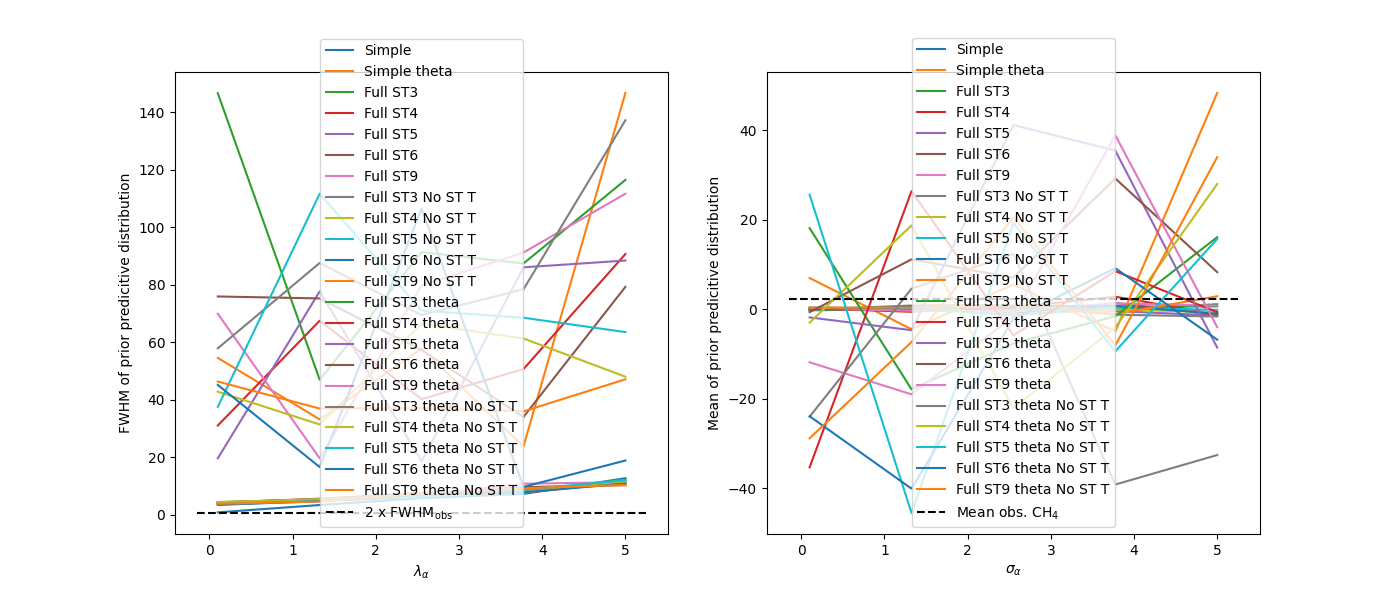

In [36]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()

labels = ['Simple', 'Simple theta',
          'Full ST3','Full ST4','Full ST5', 'Full ST6','Full ST9',
          'Full ST3 No ST T','Full ST4 No ST T','Full ST5 No ST T', 'Full ST6 No ST T','Full ST9 No ST T',
          'Full ST3 theta','Full ST4 theta','Full ST5 theta', 'Full ST6 theta','Full ST9 theta',
          'Full ST3 theta No ST T','Full ST4 theta No ST T','Full ST5 theta No ST T', 'Full ST6 theta No ST T','Full ST9 theta No ST T']
for i in range(len(labels)):
    axs[0].plot(alpha_stds, fwhms_sigma_alpha[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_ch4, 2*fwhm_obs_ch4), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel(r'$\lambda_{\alpha}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')

for i in range(len(labels)):
    axs[1].plot(alpha_stds, means_sigma_alpha[i], label=labels[i])

xlims = axs[1].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_ch4, mean_obs_ch4), 'k--', label='Mean obs. CH$_4$')
axs[1].legend()
axs[1].set_xlabel(r'$\sigma_{\alpha}$')
axs[1].set_ylabel('Mean of prior predicitive distribution')

### $\sigma_{\gamma}$

In [37]:
alpha_std = 2.0
gamma_stds = np.linspace(0.1,5,5)
lambda_beta = 1.0
lambda_delta = 1.0
lambda_epsilon = 1.0
zeta_std = 2.0
fwhms_gamma_std = [[], [], [], [], [],
                   [], [], [], [], [],
                   [], [], [], [], [],
                   [], [], [], [], [],]
mean_gamma_std = [[], [], [], [], [],
                  [], [], [], [], [],
                  [], [], [], [], [],
                  [], [], [], [], [],]
for i, gamma_std in enumerate(gamma_stds):
    full_ch4_st3, idata_full_ch4_st3 = full_model(T=data_ch4.T_air.values, X=st_3_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st4, idata_full_ch4_st4 = full_model(T=data_ch4.T_air.values, X=st_4_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st5, idata_full_ch4_st5 = full_model(T=data_ch4.T_air.values, X=st_5_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st6, idata_full_ch4_st6 = full_model(T=data_ch4.T_air.values, X=st_6_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st9, idata_full_ch4_st9 = full_model(T=data_ch4.T_air.values, X=st_9_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

    full_ch4_no_st_t_st3, idata_full_ch4_no_st_t_st3 = full_model_no_st_t(T=data_ch4.T_air.values, X=st_3_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st4, idata_full_ch4_no_st_t_st4 = full_model_no_st_t(T=data_ch4.T_air.values, X=st_4_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st5, idata_full_ch4_no_st_t_st5 = full_model_no_st_t(T=data_ch4.T_air.values, X=st_5_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st6, idata_full_ch4_no_st_t_st6 = full_model_no_st_t(T=data_ch4.T_air.values, X=st_6_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st9, idata_full_ch4_no_st_t_st9 = full_model_no_st_t(T=data_ch4.T_air.values, X=st_9_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)

    full_ch4_theta_st3, idata_full_ch4_theta_st3 = full_model_theta(T=data_ch4.T_air.values,theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st4, idata_full_ch4_theta_st4 = full_model_theta(T=data_ch4.T_air.values,theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st5, idata_full_ch4_theta_st5 = full_model_theta(T=data_ch4.T_air.values,theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st6, idata_full_ch4_theta_st6 = full_model_theta(T=data_ch4.T_air.values,theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st9, idata_full_ch4_theta_st9 = full_model_theta(T=data_ch4.T_air.values,theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_ch4.T_air.values,theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_ch4.T_air.values,theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_ch4.T_air.values,theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_ch4.T_air.values,theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st9, idata_full_ch4_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_ch4.T_air.values,theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4, y = data_ch4.F_CH4_ln.values, alpha_mu_mean=0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_full_ch4_st3, idata_full_ch4_st4, idata_full_ch4_st5, idata_full_ch4_st6, idata_full_ch4_st9, idata_full_ch4_no_st_t_st3, idata_full_ch4_no_st_t_st4, idata_full_ch4_no_st_t_st5, idata_full_ch4_no_st_t_st6, idata_full_ch4_no_st_t_st9, idata_full_ch4_theta_st3, idata_full_ch4_theta_st4, idata_full_ch4_theta_st5, idata_full_ch4_theta_st6, idata_full_ch4_theta_st9, idata_full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st9]
    models = [full_ch4_st3, full_ch4_st4, full_ch4_st5, full_ch4_st6, full_ch4_st9, full_ch4_no_st_t_st3, full_ch4_no_st_t_st4, full_ch4_no_st_t_st5, full_ch4_no_st_t_st6, full_ch4_no_st_t_st9, full_ch4_theta_st3, full_ch4_theta_st4, full_ch4_theta_st5, full_ch4_theta_st6, full_ch4_theta_st9, full_ch4_theta_no_st_t_st3, full_ch4_theta_no_st_t_st4, full_ch4_theta_no_st_t_st5, full_ch4_theta_no_st_t_st6, full_ch4_theta_no_st_t_st9]
    sts = [st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4]
    model_name = ['full','full','full','full','full',
                     'full no st t', 'full no st t','full no st t','full no st t','full no st t',
                     'full theta','full theta', 'full theta','full theta','full theta',
                     'full theta no st t','full theta no st t','full theta no st t', 'full theta no st t','full theta no st t',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']
        data_inds = np.random.choice(sts[j].shape[0], size=2000)
        pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
        if model_name[j] == 'full':
            prior_values = full_model_eq(models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
        elif model_name[j] == 'full no st t':
            prior_values = full_model_eq_no_st_t(models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
        elif model_name[j] == 'full theta':
            prior_values = full_model_eq_theta(models[j]['T_air'].eval(),models[j]['theta'].eval(), sts[j].values, pp, data_inds)
        elif model_name[j] == 'full theta no st t':
            prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(),models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(prior_values.reshape(-1, 1))
        x = np.linspace(-100,100,10001).reshape(-1,1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_gamma_std[j].append(fwhm_temp)
        mean_gamma_std[j].append(mean_temp)


Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, 

Text(0, 0.5, 'Mean of prior distribution')

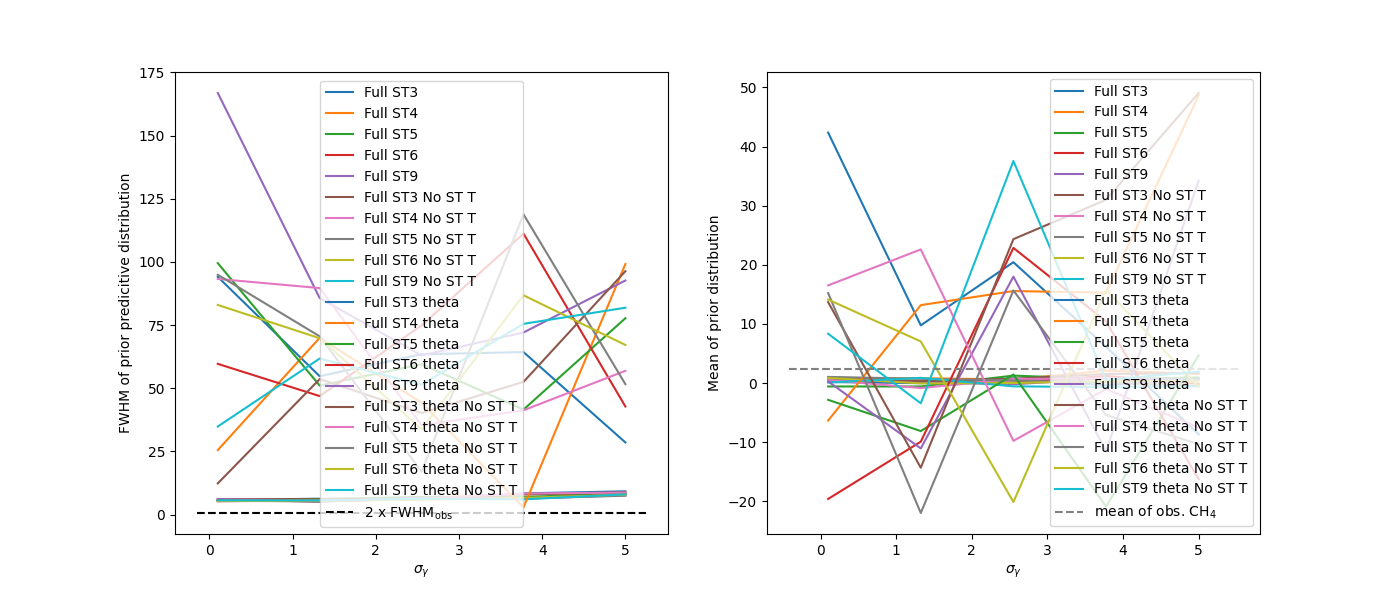

In [38]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()
labels = ['Full ST3','Full ST4','Full ST5', 'Full ST6','Full ST9',
          'Full ST3 No ST T','Full ST4 No ST T','Full ST5 No ST T', 'Full ST6 No ST T','Full ST9 No ST T',
          'Full ST3 theta','Full ST4 theta','Full ST5 theta', 'Full ST6 theta','Full ST9 theta',
          'Full ST3 theta No ST T','Full ST4 theta No ST T','Full ST5 theta No ST T', 'Full ST6 theta No ST T','Full ST9 theta No ST T']
for i in range(20):
    axs[0].plot(gamma_stds, fwhms_gamma_std[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_ch4, 2*fwhm_obs_ch4), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel('$\sigma_{\gamma}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')


for i in range(20):
    axs[1].plot(gamma_stds, mean_gamma_std[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_ch4, mean_obs_ch4), '--', color='gray', label='mean of obs. CH$_4$')
axs[1].legend()
axs[1].set_xlabel('$\sigma_{\gamma}$')
axs[1].set_ylabel('Mean of prior distribution')

### $\lambda_{\beta}$

In [39]:
alpha_std = 2.0
gamma_std = 2.0  # np.linspace(0.1,5,11)
lambda_betas = np.linspace(0.1, 5, 5)
lambda_delta = 1.0
lambda_epsilon = 1.0
zeta_std = 2.0
fwhms_lambda_beta = [[], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],]
means_lambda_beta = [[], [],
                    [], [], [], [], [],
                    [], [], [], [], [],
                    [], [], [], [], [],
                    [], [], [], [], [],]
for i, lambda_beta in enumerate(lambda_betas):
    simple_ch4, idata_simple_ch4 = simple_model(T=data_ch4.T_air.values, y=data_ch4.F_CH4_ln.values,
                                                alpha_mean=0.0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    simple_ch4_theta, idata_simple_ch4_theta = simple_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, y=data_ch4.F_CH4_ln.values,
                                                                  alpha_mean=0.0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_st3, idata_full_ch4_st3 = full_model(T=data_ch4.T_air.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st4, idata_full_ch4_st4 = full_model(T=data_ch4.T_air.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st5, idata_full_ch4_st5 = full_model(T=data_ch4.T_air.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st6, idata_full_ch4_st6 = full_model(T=data_ch4.T_air.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st9, idata_full_ch4_st9 = full_model(T=data_ch4.T_air.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

    full_ch4_no_st_t_st3, idata_full_ch4_no_st_t_st3 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st4, idata_full_ch4_no_st_t_st4 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st5, idata_full_ch4_no_st_t_st5 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st6, idata_full_ch4_no_st_t_st6 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st9, idata_full_ch4_no_st_t_st9 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)

    full_ch4_theta_st3, idata_full_ch4_theta_st3 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st4, idata_full_ch4_theta_st4 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st5, idata_full_ch4_theta_st5 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st6, idata_full_ch4_theta_st6 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st9, idata_full_ch4_theta_st9 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st9, idata_full_ch4_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_simple_ch4, idata_simple_ch4_theta, idata_full_ch4_st3, idata_full_ch4_st4, idata_full_ch4_st5, idata_full_ch4_st6, idata_full_ch4_st9, idata_full_ch4_no_st_t_st3, idata_full_ch4_no_st_t_st4, idata_full_ch4_no_st_t_st5, idata_full_ch4_no_st_t_st6, idata_full_ch4_no_st_t_st9, idata_full_ch4_theta_st3,
              idata_full_ch4_theta_st4, idata_full_ch4_theta_st5, idata_full_ch4_theta_st6, idata_full_ch4_theta_st9, idata_full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st9]
    models = [simple_ch4, simple_ch4_theta, full_ch4_st3, full_ch4_st4, full_ch4_st5, full_ch4_st6, full_ch4_st9, full_ch4_no_st_t_st3, full_ch4_no_st_t_st4, full_ch4_no_st_t_st5, full_ch4_no_st_t_st6, full_ch4_no_st_t_st9, full_ch4_theta_st3,
              full_ch4_theta_st4, full_ch4_theta_st5, full_ch4_theta_st6, full_ch4_theta_st9, full_ch4_theta_no_st_t_st3, full_ch4_theta_no_st_t_st4, full_ch4_theta_no_st_t_st5, full_ch4_theta_no_st_t_st6, full_ch4_theta_no_st_t_st9]
    sts = [None, None, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4,
           st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4]
    model_name = ['simple', 'simple theta',
                  'full', 'full', 'full', 'full', 'full',
                  'full no st t', 'full no st t', 'full no st t', 'full no st t', 'full no st t',
                  'full theta', 'full theta', 'full theta', 'full theta', 'full theta',
                  'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']

        if sts[j] is None:
            data_inds = np.random.choice(
                simple_ch4['T_air'].eval().shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'simple':
                prior_values = simple_model_eq(models[j]['T_air'].eval(
                ), pp, data_inds)
            elif model_name[j] == 'simple theta':
                prior_values = simple_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), pp, data_inds)
        else:
            data_inds = np.random.choice(sts[j].shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'full':
                prior_values = full_model_eq(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full no st t':
                prior_values = full_model_eq_no_st_t(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta':
                prior_values = full_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta no st t':
                prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
            prior_values.reshape(-1, 1))
        x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_lambda_beta[j].append(fwhm_temp)
        means_lambda_beta[j].append(mean_temp)

Sampling: [alpha, beta, obs, sigma]
Sampling: [alpha, beta, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gam

Text(0, 0.5, 'Mean of prior predicitive distribution')

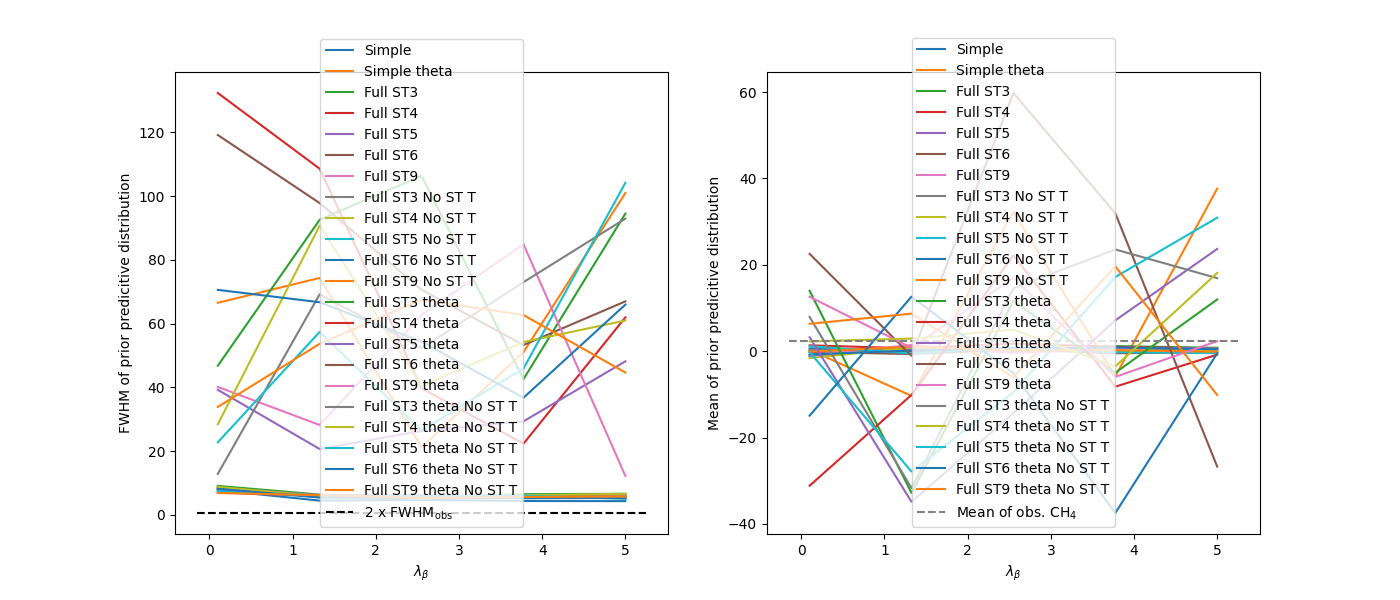

In [40]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()
labels = ['Simple', 'Simple theta',
          'Full ST3','Full ST4','Full ST5', 'Full ST6','Full ST9',
          'Full ST3 No ST T','Full ST4 No ST T','Full ST5 No ST T', 'Full ST6 No ST T','Full ST9 No ST T',
          'Full ST3 theta','Full ST4 theta','Full ST5 theta', 'Full ST6 theta','Full ST9 theta',
          'Full ST3 theta No ST T','Full ST4 theta No ST T','Full ST5 theta No ST T', 'Full ST6 theta No ST T','Full ST9 theta No ST T']
for i in range(len(labels)):
    axs[0].plot(lambda_betas, fwhms_lambda_beta[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_ch4, 2*fwhm_obs_ch4), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel(r'$\lambda_{\beta}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')


for i in range(len(labels)):
    axs[1].plot(lambda_betas, means_lambda_beta[i], label=labels[i])

xlims = axs[1].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_ch4, mean_obs_ch4), '--', color='gray', label='Mean of obs. CH$_4$')
axs[1].legend()
axs[1].set_xlabel(r'$\lambda_{\beta}$')
axs[1].set_ylabel('Mean of prior predicitive distribution')

### $\lambda_{\delta}$

In [41]:
alpha_std = 2.0
gamma_std = 2.0
lambda_beta = 1.0
lambda_deltas = np.linspace(0.1, 5, 5)
lambda_epsilon = 1.0
zeta_std = 2.0
fwhms_lambda_delta = [
                     [], [], [], [], [],
                     [], [], [], [], [],]
means_lambda_delta = [
                    [], [], [], [], [],
                    [], [], [], [], [],]
for i, lambda_delta in enumerate(lambda_deltas):

    full_ch4_st3, idata_full_ch4_st3 = full_model(T=data_ch4.T_air.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st4, idata_full_ch4_st4 = full_model(T=data_ch4.T_air.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st5, idata_full_ch4_st5 = full_model(T=data_ch4.T_air.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st6, idata_full_ch4_st6 = full_model(T=data_ch4.T_air.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st9, idata_full_ch4_st9 = full_model(T=data_ch4.T_air.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

    full_ch4_theta_st3, idata_full_ch4_theta_st3 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st4, idata_full_ch4_theta_st4 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st5, idata_full_ch4_theta_st5 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st6, idata_full_ch4_theta_st6 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st9, idata_full_ch4_theta_st9 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_full_ch4_st3, idata_full_ch4_st4, idata_full_ch4_st5, idata_full_ch4_st6, idata_full_ch4_st9, idata_full_ch4_theta_st3,
              idata_full_ch4_theta_st4, idata_full_ch4_theta_st5, idata_full_ch4_theta_st6, idata_full_ch4_theta_st9,]
    models = [full_ch4_st3, full_ch4_st4, full_ch4_st5, full_ch4_st6, full_ch4_st9, full_ch4_theta_st3,
              full_ch4_theta_st4, full_ch4_theta_st5, full_ch4_theta_st6, full_ch4_theta_st9,]
    sts = [st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4]
    model_name = [
                  'full', 'full', 'full', 'full', 'full',
                  'full theta', 'full theta', 'full theta', 'full theta', 'full theta',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']

        if sts[j] is None:
            data_inds = np.random.choice(
                simple_ch4['T_air'].eval().shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'simple':
                prior_values = simple_model_eq(models[j]['T_air'].eval(
                ), pp, data_inds)
            elif model_name[j] == 'simple theta':
                prior_values = simple_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), pp, data_inds)
        else:
            data_inds = np.random.choice(sts[j].shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'full':
                prior_values = full_model_eq(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full no st t':
                prior_values = full_model_eq_no_st_t(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta':
                prior_values = full_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta no st t':
                prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
            prior_values.reshape(-1, 1))
        x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_lambda_delta[j].append(fwhm_temp)
        means_lambda_delta[j].append(mean_temp)


Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Samp

Text(0, 0.5, 'Mean of prior predicitive distribution')

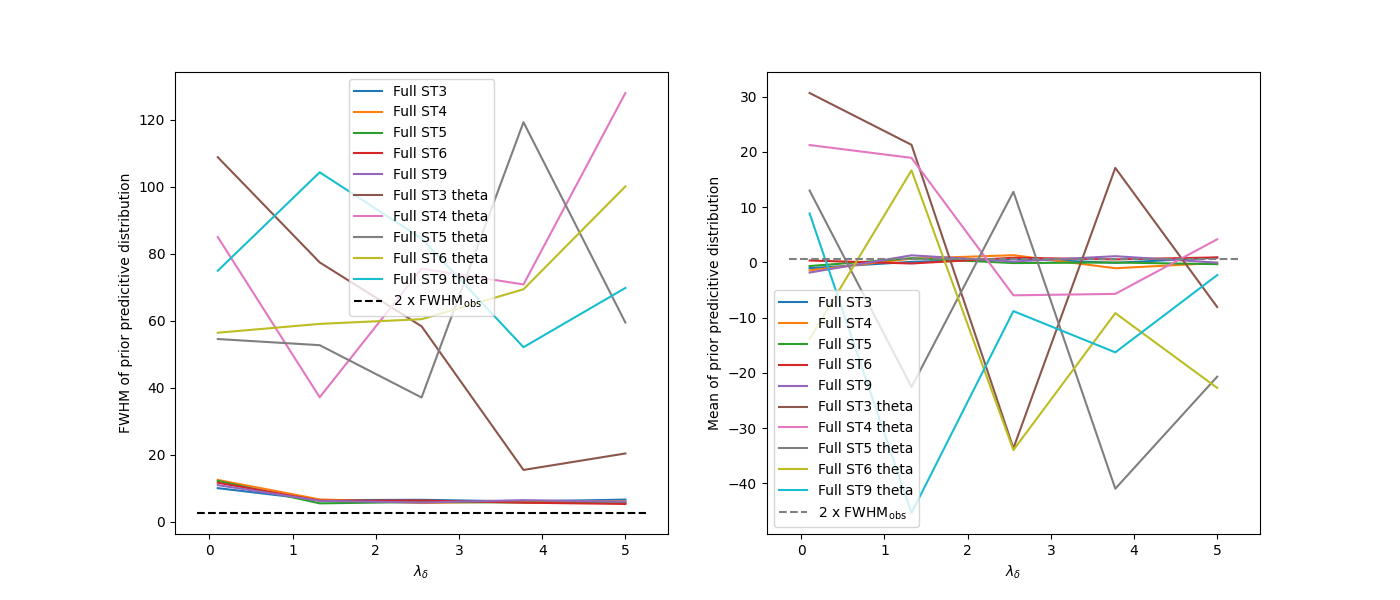

In [ ]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()
labels = ['Full ST3','Full ST4','Full ST5','Full ST6','Full ST9', 'Full ST3 theta','Full ST4 theta','Full ST5 theta','Full ST6 theta','Full ST9 theta']
for i in range(len(labels)):
    axs[0].plot(lambda_deltas, fwhms_lambda_delta[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_ch4, 2*fwhm_obs_ch4), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel(r'$\lambda_{\delta}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')

for i in range(len(labels)):
    axs[1].plot(lambda_deltas, means_lambda_delta[i], label=labels[i])

xlims = axs[1].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_ch4, mean_obs_ch4), '--', color='gray', label='Mean of obs. CH$_4$')
axs[1].legend()
axs[1].set_xlabel(r'$\lambda_{\delta}$')
axs[1].set_ylabel('Mean of prior predicitive distribution')

### $\lambda_{\epsilon}$

In [42]:
alpha_std = 2.0
gamma_std = 2.0 #np.linspace(0.1,5,11)
lambda_beta = 1.0
lambda_delta = 1.0
lambda_epsilons = np.linspace(0.1, 5, 5)
zeta_std = 2.0
fwhms_lambda_epsilon = [[], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],
                     [], [], [], [], [],]
means_lambda_epsilon = [[], [],
                    [], [], [], [], [],
                    [], [], [], [], [],
                    [], [], [], [], [],
                    [], [], [], [], [],]
for i, lambda_epsilon in enumerate(lambda_epsilons):
    simple_ch4, idata_simple_ch4 = simple_model(T=data_ch4.T_air.values, y=data_ch4.F_CH4_ln.values,
                                                alpha_mean=0.0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    simple_ch4_theta, idata_simple_ch4_theta = simple_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, y=data_ch4.F_CH4_ln.values,
                                                                  alpha_mean=0.0, alpha_std=alpha_std,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_st3, idata_full_ch4_st3 = full_model(T=data_ch4.T_air.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st4, idata_full_ch4_st4 = full_model(T=data_ch4.T_air.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st5, idata_full_ch4_st5 = full_model(T=data_ch4.T_air.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st6, idata_full_ch4_st6 = full_model(T=data_ch4.T_air.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
    full_ch4_st9, idata_full_ch4_st9 = full_model(T=data_ch4.T_air.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                                  alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

    full_ch4_no_st_t_st3, idata_full_ch4_no_st_t_st3 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st4, idata_full_ch4_no_st_t_st4 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st5, idata_full_ch4_no_st_t_st5 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st6, idata_full_ch4_no_st_t_st6 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
    full_ch4_no_st_t_st9, idata_full_ch4_no_st_t_st9 = full_model_no_st_t(
        T=data_ch4.T_air.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)

    full_ch4_theta_st3, idata_full_ch4_theta_st3 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st4, idata_full_ch4_theta_st4 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st5, idata_full_ch4_theta_st5 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st6, idata_full_ch4_theta_st6 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st9, idata_full_ch4_theta_st9 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st9, idata_full_ch4_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_simple_ch4, idata_simple_ch4_theta, idata_full_ch4_st3, idata_full_ch4_st4, idata_full_ch4_st5, idata_full_ch4_st6, idata_full_ch4_st9, idata_full_ch4_no_st_t_st3, idata_full_ch4_no_st_t_st4, idata_full_ch4_no_st_t_st5, idata_full_ch4_no_st_t_st6, idata_full_ch4_no_st_t_st9, idata_full_ch4_theta_st3,
              idata_full_ch4_theta_st4, idata_full_ch4_theta_st5, idata_full_ch4_theta_st6, idata_full_ch4_theta_st9, idata_full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st9]
    models = [simple_ch4, simple_ch4_theta, full_ch4_st3, full_ch4_st4, full_ch4_st5, full_ch4_st6, full_ch4_st9, full_ch4_no_st_t_st3, full_ch4_no_st_t_st4, full_ch4_no_st_t_st5, full_ch4_no_st_t_st6, full_ch4_no_st_t_st9, full_ch4_theta_st3,
              full_ch4_theta_st4, full_ch4_theta_st5, full_ch4_theta_st6, full_ch4_theta_st9, full_ch4_theta_no_st_t_st3, full_ch4_theta_no_st_t_st4, full_ch4_theta_no_st_t_st5, full_ch4_theta_no_st_t_st6, full_ch4_theta_no_st_t_st9]
    sts = [None, None, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4,
           st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4]
    model_name = ['simple', 'simple theta',
                  'full', 'full', 'full', 'full', 'full',
                  'full no st t', 'full no st t', 'full no st t', 'full no st t', 'full no st t',
                  'full theta', 'full theta', 'full theta', 'full theta', 'full theta',
                  'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']

        if sts[j] is None:
            data_inds = np.random.choice(
                simple_ch4['T_air'].eval().shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'simple':
                prior_values = simple_model_eq(models[j]['T_air'].eval(
                ), pp, data_inds)
            elif model_name[j] == 'simple theta':
                prior_values = simple_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), pp, data_inds)
        else:
            data_inds = np.random.choice(sts[j].shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'full':
                prior_values = full_model_eq(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full no st t':
                prior_values = full_model_eq_no_st_t(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta':
                prior_values = full_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta no st t':
                prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
            prior_values.reshape(-1, 1))
        x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_lambda_epsilon[j].append(fwhm_temp)
        means_lambda_epsilon[j].append(mean_temp)


Sampling: [alpha, beta, obs, sigma]
Sampling: [alpha, beta, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gam

Text(0, 0.5, 'Mean of prior predicitive distribution')

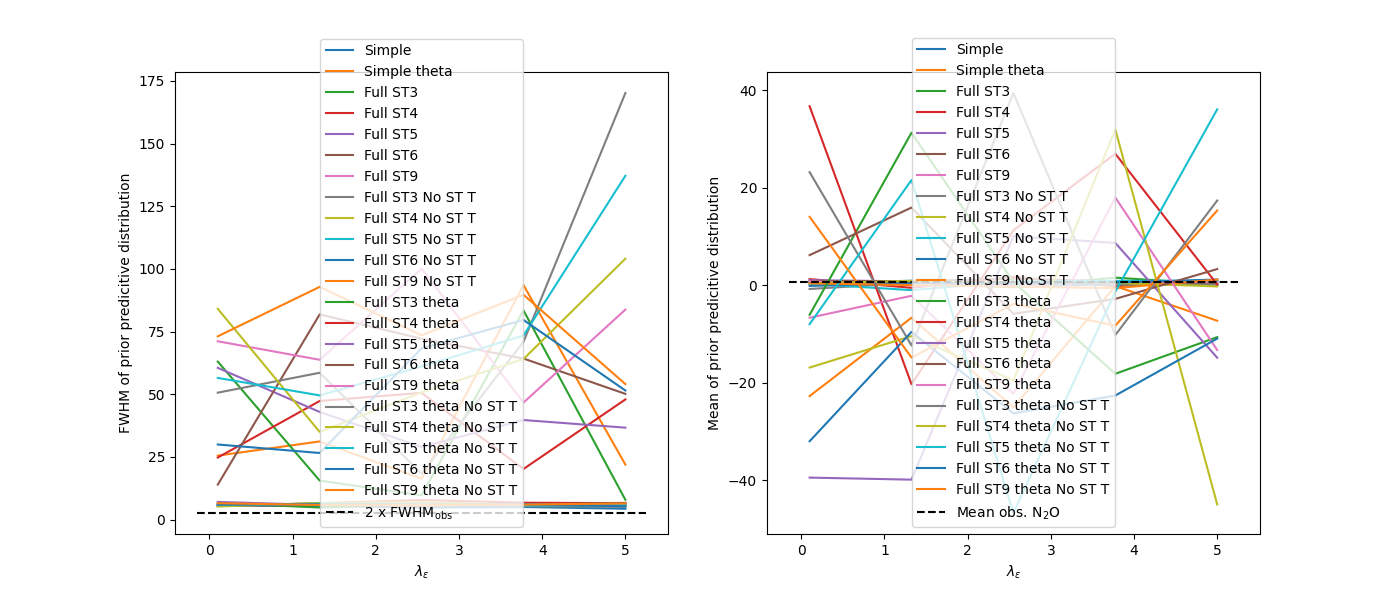

In [ ]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()

labels = ['Simple', 'Simple theta',
          'Full ST3','Full ST4','Full ST5', 'Full ST6','Full ST9',
          'Full ST3 No ST T','Full ST4 No ST T','Full ST5 No ST T', 'Full ST6 No ST T','Full ST9 No ST T',
          'Full ST3 theta','Full ST4 theta','Full ST5 theta', 'Full ST6 theta','Full ST9 theta',
          'Full ST3 theta No ST T','Full ST4 theta No ST T','Full ST5 theta No ST T', 'Full ST6 theta No ST T','Full ST9 theta No ST T']
for i in range(len(labels)):
    axs[0].plot(lambda_epsilons, fwhms_lambda_epsilon[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_ch4, 2*fwhm_obs_ch4), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel(r'$\lambda_{\epsilon}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')

for i in range(len(labels)):
    axs[1].plot(lambda_epsilons, means_lambda_epsilon[i], label=labels[i])

xlims = axs[1].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_ch4, mean_obs_ch4), 'k--', label='Mean of obs. CH$_4$')
axs[1].legend()
axs[1].set_xlabel(r'$\lambda_{\epsilon}$')
axs[1].set_ylabel('Mean of prior predicitive distribution')

### $\sigma_{\zeta}$

In [43]:
alpha_std = 2.0
gamma_std = 2.0
lambda_beta = 1.0
lambda_delta = 1.0
lambda_epsilons = np.linspace(0.1, 5, 5)
zeta_std = 2.0
fwhms_sigma_zeta = [
                     [], [], [], [], [],
                     [], [], [], [], [],]
means_sigma_zeta = [
                    [], [], [], [], [],
                    [], [], [], [], [],]
for i, lambda_epsilon in enumerate(lambda_epsilons):
    full_ch4_theta_st3, idata_full_ch4_theta_st3 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st4, idata_full_ch4_theta_st4 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st5, idata_full_ch4_theta_st5 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st6, idata_full_ch4_theta_st6 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_st9, idata_full_ch4_theta_st9 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values,
                                                                    alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)
    full_ch4_theta_no_st_t_st9, idata_full_ch4_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4,
                                                                                            y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=alpha_std, gamma_std=gamma_std, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=zeta_std)

    idatas = [idata_full_ch4_theta_st3,
              idata_full_ch4_theta_st4, idata_full_ch4_theta_st5, idata_full_ch4_theta_st6, idata_full_ch4_theta_st9, idata_full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st9]
    models = [full_ch4_theta_st3,
              full_ch4_theta_st4, full_ch4_theta_st5, full_ch4_theta_st6, full_ch4_theta_st9, full_ch4_theta_no_st_t_st3, full_ch4_theta_no_st_t_st4, full_ch4_theta_no_st_t_st5, full_ch4_theta_no_st_t_st6, full_ch4_theta_no_st_t_st9]
    sts = [
           st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4]
    model_name = [
                  'full theta', 'full theta', 'full theta', 'full theta', 'full theta',
                  'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t',]
    for j, idata in enumerate(idatas):
        prior = idata['prior']

        if sts[j] is None:
            data_inds = np.random.choice(
                simple_ch4['T_air'].eval().shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'simple':
                prior_values = simple_model_eq(models[j]['T_air'].eval(
                ), pp, data_inds)
            elif model_name[j] == 'simple theta':
                prior_values = simple_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), pp, data_inds)
        else:
            data_inds = np.random.choice(sts[j].shape[0], size=2000)
            pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
            if model_name[j] == 'full':
                prior_values = full_model_eq(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full no st t':
                prior_values = full_model_eq_no_st_t(
                    models[j]['T_air'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta':
                prior_values = full_model_eq_theta(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)
            elif model_name[j] == 'full theta no st t':
                prior_values = full_model_eq_theta_no_st_t(models[j]['T_air'].eval(
                ), models[j]['theta'].eval(), sts[j].values, pp, data_inds)

        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
            prior_values.reshape(-1, 1))
        x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        kde_values = np.exp(kde.score_samples(x))
        fwhm_temp, mean_temp = FWHM(x, kde_values)
        fwhms_sigma_zeta[j].append(fwhm_temp)
        means_sigma_zeta[j].append(mean_temp)


Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gamma, gamma_mu, obs,

Text(0, 0.5, 'Mean of prior predicitive distribution')

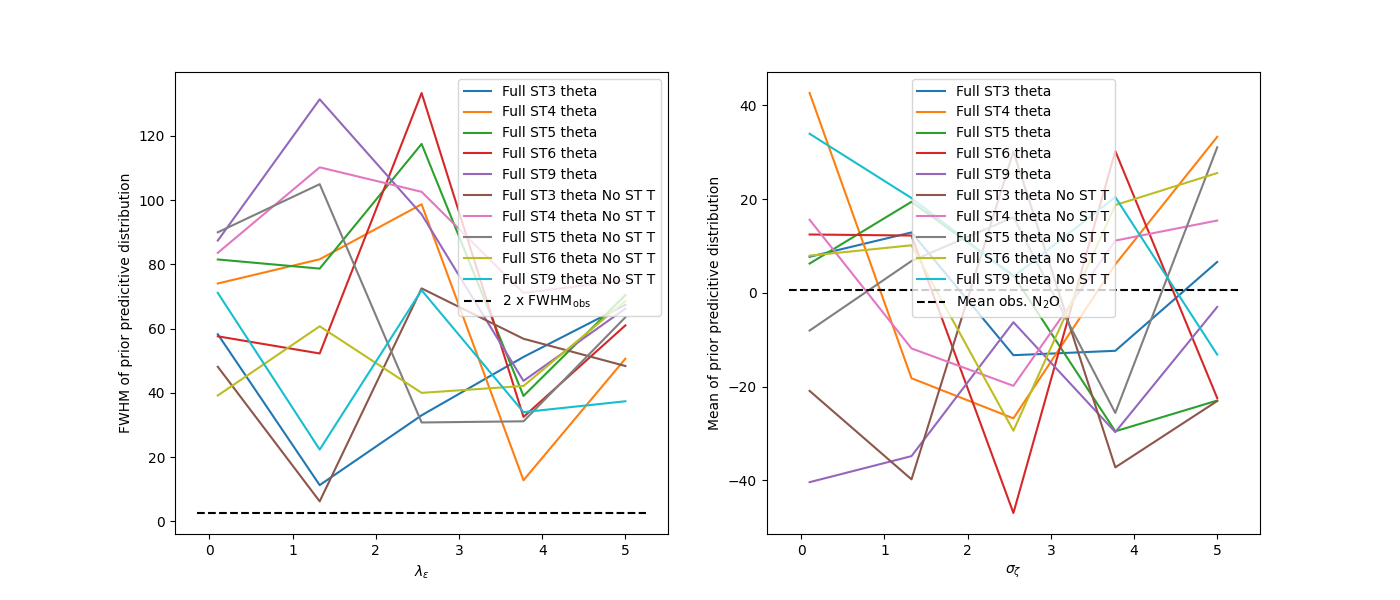

In [ ]:
fig, axs = plt.subplots(figsize=(14,6), ncols=2)
axs = axs.flatten()

labels = [
          'Full ST3 theta','Full ST4 theta','Full ST5 theta', 'Full ST6 theta','Full ST9 theta',
          'Full ST3 theta No ST T','Full ST4 theta No ST T','Full ST5 theta No ST T', 'Full ST6 theta No ST T','Full ST9 theta No ST T']
for i in range(len(labels)):
    axs[0].plot(lambda_epsilons, fwhms_sigma_zeta[i], label=labels[i])

xlims = axs[0].get_xlim()
axs[0].plot((xlims[0], xlims[1]),(2*fwhm_obs_ch4, 2*fwhm_obs_ch4), 'k--', label='2 x FWHM$_{\mathrm{obs}}$')
axs[0].legend()
axs[0].set_xlabel(r'$\lambda_{\epsilon}$')
axs[0].set_ylabel('FWHM of prior predicitive distribution')

for i in range(len(labels)):
    axs[1].plot(lambda_epsilons, means_sigma_zeta[i], label=labels[i])

xlims = axs[1].get_xlim()
axs[1].plot((xlims[0], xlims[1]),(mean_obs_ch4, mean_obs_ch4), 'k--', label='Mean of obs. CH$_4$')
axs[1].legend()
axs[1].set_xlabel(r'$\sigma_{\zeta}$')
axs[1].set_ylabel('Mean of prior predicitive distribution')

## Choose values
These values are used in the notebook [GHG_models_fit.ipynb](GHG_models_fit.ipynb)
$$
\begin{align*}
\sigma_\alpha = 2.0 \\
\sigma_\gamma = 2.0 \\
\sigma_\zeta = 2.0 \\
\lambda_\beta = 1.0 \\
\lambda_\delta = 1.0 \\
\lambda_\epsilon = 1.0 \\

\end{align*}
$$

## Plot prior predicitive distributions

In [22]:
def plot_prior_predictive(obs, prior_values, xlabel, ax, title=''):
    fs=16
    ls=14
    bins, counts, _ = ax.hist(obs, bins=100, color='goldenrod', density=True, label=f'Measured {xlabel}')
    bins, counts, _ = ax.hist(prior_values, bins = np.linspace(-100,100,10001), alpha=0.75, density=True, label='Prior')

    #ax.legend(loc='best')
    ax.tick_params(axis='both', labelsize=ls)
    ax.set_title(title, fontsize=fs)

    kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(obs.reshape(-1, 1))
    x = np.linspace(-100,100,10001).reshape(-1,1)
    kde_values = np.exp(kde.score_samples(x))
    fwhm_obs, mean_obs = FWHM(x, kde_values)


    obs_max_x = x[np.argmax(kde_values)]
    xmax = obs_max_x + 5*fwhm_obs
    xmin = obs_max_x - 5*fwhm_obs
    ax.set_xlim([xmin, xmax])

    kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(prior_values.reshape(-1, 1))
    kde_values = np.exp(kde.score_samples(x))
    fwhm_model, mean_model = FWHM(x, kde_values)

    # ymin, ymax = ax.get_ylim()
    # xmin, xmax = ax.get_xlim()
    ax.text(0.05, 0.75, f'FWHM$_{{\mathrm{{model}}}}: {np.round(fwhm_model,2)}$', transform=ax.transAxes)
    ax.text(0.05, 0.65, f'FWHM$_{{\mathrm{{obs}}}}: {np.round(fwhm_obs,2)}$', transform=ax.transAxes)
    ax.text(0.05, 0.55, f'$\mu_{{\mathrm{{model}}}}: {np.round(mean_model,2)}$',transform=ax.transAxes)
    ax.text(0.05, 0.45, f'$\mu_{{\mathrm{{obs}}}}: {np.round(mean_obs,2)}$', transform=ax.transAxes)


Sampling: [alpha, beta, obs, sigma]
Sampling: [alpha, beta, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, delta, gamma, gamma_mu, obs, sigma, zeta]
Sampling: [alpha, beta, gam

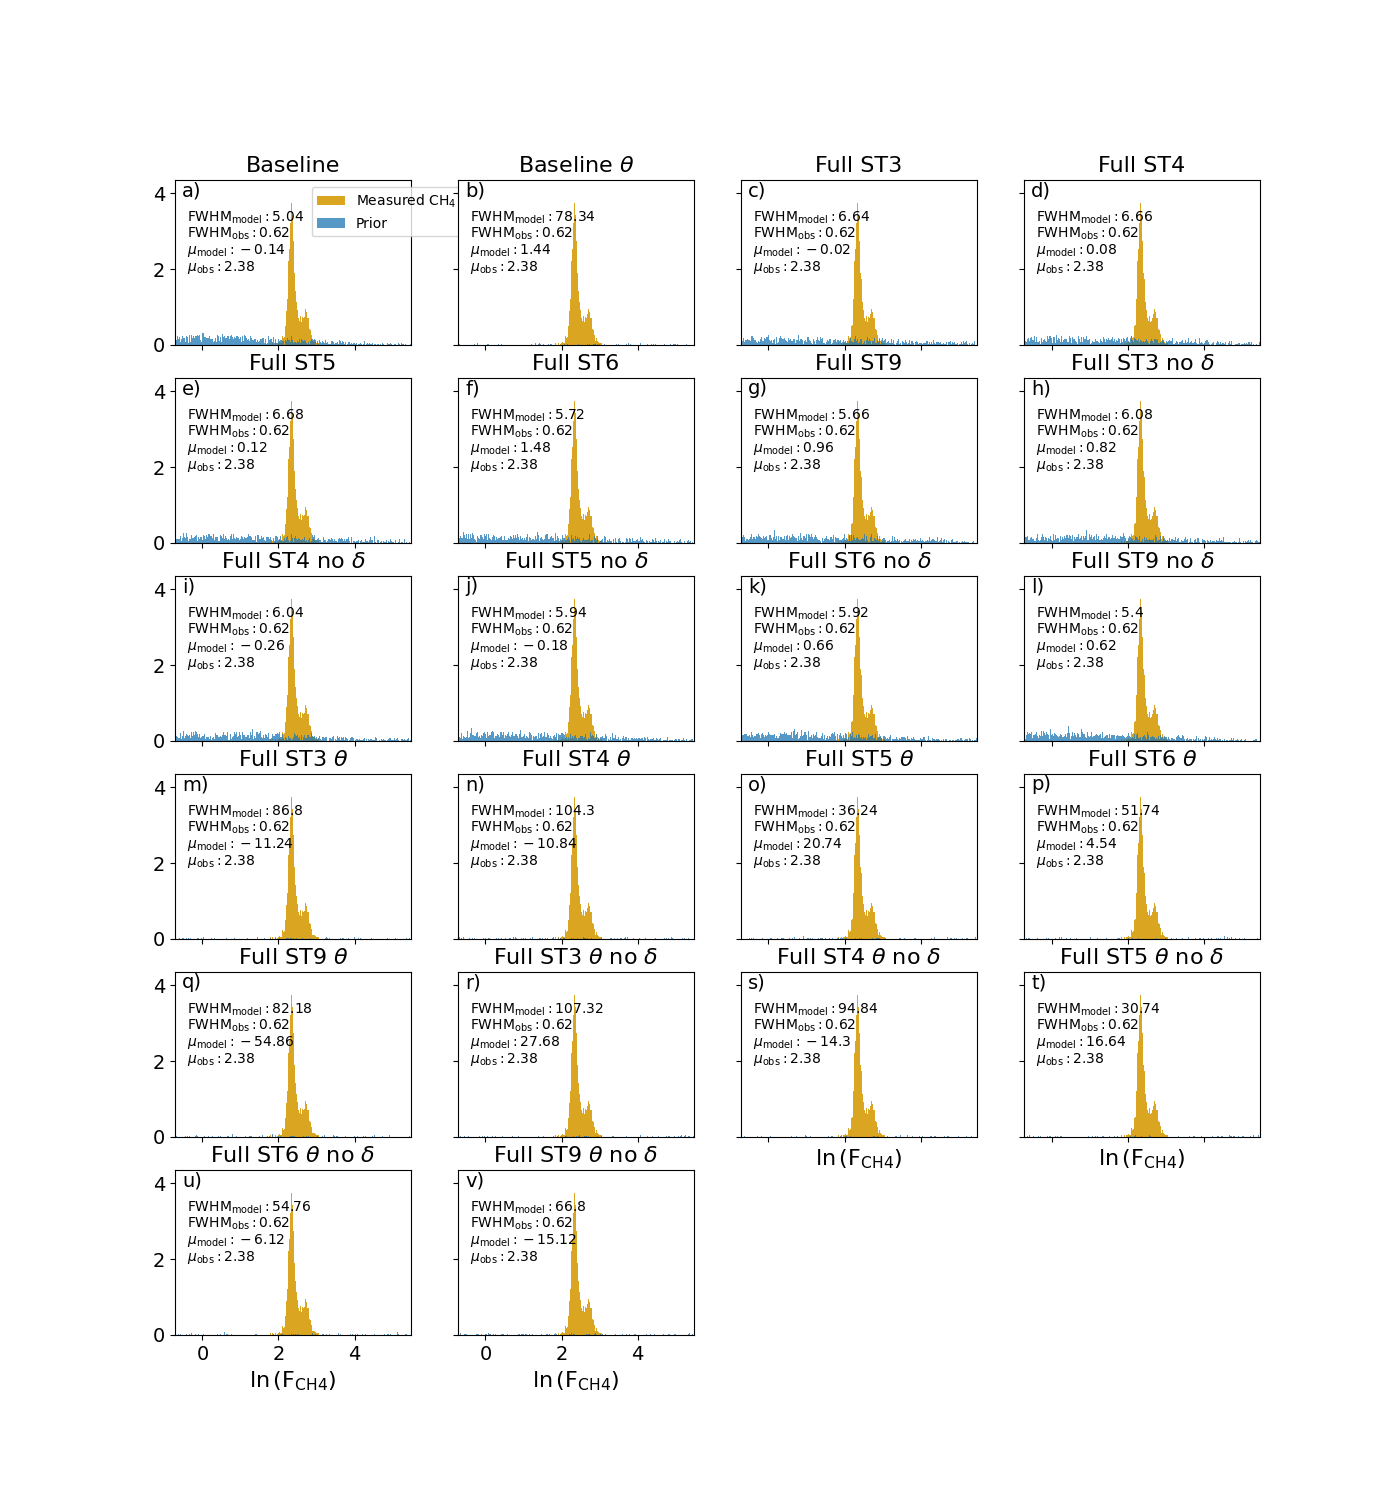

In [23]:
fig, axs = plt.subplots(figsize=(14, 15), nrows=6,
                        ncols=4, sharex=True, sharey=True)
axs = axs.flatten()
sigma_alpha = 2.0
sigma_zeta = 2.0
sigma_gamma = 2.0
lambda_beta = 1.0
lambda_delta = 1.0
lambda_epsilon = 1.0

simple_ch4, idata_simple_ch4 = simple_model(T=data_ch4.T_air.values, y=data_ch4.F_CH4_ln.values,
                                            alpha_mean=0.0, alpha_std=sigma_alpha,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
simple_ch4_theta, idata_simple_ch4_theta = simple_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, y=data_ch4.F_CH4_ln.values,
                                                              alpha_mean=0.0, alpha_std=sigma_alpha,  lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_ch4_st3, idata_full_ch4_st3 = full_model(T=data_ch4.T_air.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                              alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
full_ch4_st4, idata_full_ch4_st4 = full_model(T=data_ch4.T_air.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                              alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
full_ch4_st5, idata_full_ch4_st5 = full_model(T=data_ch4.T_air.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                              alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
full_ch4_st6, idata_full_ch4_st6 = full_model(T=data_ch4.T_air.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                              alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)
full_ch4_st9, idata_full_ch4_st9 = full_model(T=data_ch4.T_air.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0,
                                              alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon)

full_ch4_no_st_t_st3, idata_full_ch4_no_st_t_st3 = full_model_no_st_t(
    T=data_ch4.T_air.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
full_ch4_no_st_t_st4, idata_full_ch4_no_st_t_st4 = full_model_no_st_t(
    T=data_ch4.T_air.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
full_ch4_no_st_t_st5, idata_full_ch4_no_st_t_st5 = full_model_no_st_t(
    T=data_ch4.T_air.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
full_ch4_no_st_t_st6, idata_full_ch4_no_st_t_st6 = full_model_no_st_t(
    T=data_ch4.T_air.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)
full_ch4_no_st_t_st9, idata_full_ch4_no_st_t_st9 = full_model_no_st_t(
    T=data_ch4.T_air.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon)

full_ch4_theta_st3, idata_full_ch4_theta_st3 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4, y=data_ch4.F_CH4_ln.values,
                                                                alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_ch4_theta_st4, idata_full_ch4_theta_st4 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4, y=data_ch4.F_CH4_ln.values,
                                                                alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_ch4_theta_st5, idata_full_ch4_theta_st5 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4, y=data_ch4.F_CH4_ln.values,
                                                                alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_ch4_theta_st6, idata_full_ch4_theta_st6 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4, y=data_ch4.F_CH4_ln.values,
                                                                alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_ch4_theta_st9, idata_full_ch4_theta_st9 = full_model_theta(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4, y=data_ch4.F_CH4_ln.values,
                                                                alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_delta=lambda_delta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)

full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st3 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_3_ch4,
                                                                                        y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st4 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_4_ch4,
                                                                                        y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st5 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_5_ch4,
                                                                                        y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st6 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_6_ch4,
                                                                                        y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)
full_ch4_theta_no_st_t_st9, idata_full_ch4_theta_no_st_t_st9 = full_model_theta_no_st_t(T=data_ch4.T_air.values, theta=data_ch4.soil_moisture_tomst_mean.values, X=st_9_ch4,
                                                                                        y=data_ch4.F_CH4_ln.values, alpha_mu_mean=0.0, alpha_mu_std=sigma_alpha, gamma_std=sigma_gamma, lambda_beta=lambda_beta, lambda_epsilon=lambda_epsilon, zeta_std=sigma_zeta)

idatas = [idata_simple_ch4, idata_simple_ch4_theta, idata_full_ch4_st3, idata_full_ch4_st4, idata_full_ch4_st5, idata_full_ch4_st6, idata_full_ch4_st9, idata_full_ch4_no_st_t_st3, idata_full_ch4_no_st_t_st4, idata_full_ch4_no_st_t_st5, idata_full_ch4_no_st_t_st6, idata_full_ch4_no_st_t_st9, idata_full_ch4_theta_st3,
          idata_full_ch4_theta_st4, idata_full_ch4_theta_st5, idata_full_ch4_theta_st6, idata_full_ch4_theta_st9, idata_full_ch4_theta_no_st_t_st3, idata_full_ch4_theta_no_st_t_st4, idata_full_ch4_theta_no_st_t_st5, idata_full_ch4_theta_no_st_t_st6, idata_full_ch4_theta_no_st_t_st9]
models = [simple_ch4, simple_ch4_theta, full_ch4_st3, full_ch4_st4, full_ch4_st5, full_ch4_st6, full_ch4_st9, full_ch4_no_st_t_st3, full_ch4_no_st_t_st4, full_ch4_no_st_t_st5, full_ch4_no_st_t_st6, full_ch4_no_st_t_st9, full_ch4_theta_st3,
          full_ch4_theta_st4, full_ch4_theta_st5, full_ch4_theta_st6, full_ch4_theta_st9, full_ch4_theta_no_st_t_st3, full_ch4_theta_no_st_t_st4, full_ch4_theta_no_st_t_st5, full_ch4_theta_no_st_t_st6, full_ch4_theta_no_st_t_st9]
sts = [None, None, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4,
       st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4, st_3_ch4, st_4_ch4, st_5_ch4, st_6_ch4, st_9_ch4]
model_name = ['simple', 'simple theta',
              'full', 'full', 'full', 'full', 'full',
              'full no st t', 'full no st t', 'full no st t', 'full no st t', 'full no st t',
              'full theta', 'full theta', 'full theta', 'full theta', 'full theta',
              'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t', 'full theta no st t',]

titles = [r'Baseline',r'Baseline $\theta$', r'Full ST3', r'Full ST4', r'Full ST5', r'Full ST6', r'Full ST9',
          r'Full ST3 no $\delta$', r'Full ST4 no $\delta$', r'Full ST5 no $\delta$', r'Full ST6 no $\delta$', r'Full ST9 no $\delta$',
          r'Full ST3 $\theta$', r'Full ST4 $\theta$', r'Full ST5 $\theta$', r'Full ST6 $\theta$', r'Full ST9 $\theta$',
          r'Full ST3 $\theta$ no $\delta$', r'Full ST4 $\theta$ no $\delta$', r'Full ST5 $\theta$ no $\delta$', r'Full ST6 $\theta$ no $\delta$', r'Full ST9 $\theta$ no $\delta$',]
subplot_labels = ['a)', 'b)', 
                  'c)', 'd)', 'e)', 'f)' ,'g)','h)',
                  'i)', 'j)', 'k)', 'l)' ,'m)','n)',
                  'o)', 'p)', 'q)', 'r)' ,'s)','t)',
                  'u)', 'v)', 'w)', 'x)' ,'y)','z)',]
for i, idata in enumerate(idatas):
    prior = idata['prior']
    if sts[i] is None:
        data_inds = np.random.choice(
            simple_ch4['T_air'].eval().shape[0], size=2000)
        pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
        if model_name[i] == 'simple':
            prior_values = simple_model_eq(models[i]['T_air'].eval(
            ), pp, data_inds)
        elif model_name[i] == 'simple theta':
            prior_values = simple_model_eq_theta(models[i]['T_air'].eval(
            ), models[i]['theta'].eval(), pp, data_inds)
    else:
        data_inds = np.random.choice(sts[i].shape[0], size=2000)
        pp = {k: np.squeeze(v.to_numpy()) for k, v in prior.items()}
        if model_name[i] == 'full':
            prior_values = full_model_eq(
                models[i]['T_air'].eval(), sts[i].values, pp, data_inds)
        elif model_name[i] == 'full no st t':
            prior_values = full_model_eq_no_st_t(
                models[i]['T_air'].eval(), sts[i].values, pp, data_inds)
        elif model_name[i] == 'full theta':
            prior_values = full_model_eq_theta(models[i]['T_air'].eval(
            ), models[i]['theta'].eval(), sts[i].values, pp, data_inds)
        elif model_name[i] == 'full theta no st t':
            prior_values = full_model_eq_theta_no_st_t(models[i]['T_air'].eval(
            ), models[i]['theta'].eval(), sts[i].values, pp, data_inds)

        # kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(
        #     prior_values.reshape(-1, 1))
        # x = np.linspace(-100, 100, 10001).reshape(-1, 1)
        # kde_values = np.exp(kde.score_samples(x))
        # fwhm_temp, mean_temp = FWHM(x, kde_values)
        # fwhms_lambda_epsilon[j].append(fwhm_temp)
        # means_lambda_epsilon[j].append(mean_temp)

    plot_prior_predictive(obs_ch4, prior_values, 'CH$_4$',
                          ax=axs[i], title=titles[i])

    if i == 21 or i == 20 or i==19 or i==18:
        axs[i].set_xlabel('$\ln{(\mathrm{F}_\mathrm{CH4})}$', fontsize=16)
    # if i == 0 or i == 4 or i == 8 or i==12 or i==16 or i==20:
    #     axs[i].set_ylabel('Normalized frequency (-)', fontsize=16)
    axs[i].text(0.03, 0.9, subplot_labels[i],
                transform=axs[i].transAxes, fontsize=14)

axs[0].legend(loc='best', bbox_to_anchor=(0.55, 0.5, 0.5, 0.5))
for ax in axs[-2:]:
    ax.remove()

## Choose values
These values are used in the notebook [GHG_models_fit.ipynb](GHG_models_fit.ipynb)
$$
\begin{align*}
\sigma_\gamma = 2.0 \\
\lambda_\beta = 1.0 \\
\lambda_\delta = 1.0 \\
\lambda_\epsilon = 1.0
\end{align*}
$$